In [8733]:
import pandas as pd
df = pd.read_csv("experiment_results.csv")

In [8734]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

In [8735]:
df['train_type'] = df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[1] + "_" + df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[3]

In [8736]:
df['amp_type'] = df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[0] 

In [8737]:
df['train_length'] = df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[2] 

In [8738]:
df['modulation'] = df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[4] 
df['seed/version'] = df['train_label'].str.split('/', expand=True)[2].str.split('_', expand=True)[5] 

In [8739]:
df['playing_rms_ratio'] = df['playing_est_rms'] / df['playing_ref_rms']

In [8740]:
df.train_type.unique()

array(['NBS_short', 'DIguitar_short', 'NAB_short', 'NO_short',
       'NAS_short', 'RNS_short', 'sweep_short', 'sweep_long'],
      dtype=object)

In [8741]:
df.replace('NBS_short', 'NoiseBurstsSweeps', inplace=True)
df.replace('NAS_short', 'NoiseAndSweeps', inplace=True)
df.replace('NAB_short', 'NoiseAndBursts', inplace=True)
df.replace('NO_short', 'NoiseOnly', inplace=True)
df.replace('RNS_short', 'GuitarNoiseSweeps', inplace=True)
df.replace('DIguitar_short', 'Guitar', inplace=True)
df.replace('sweep_short', 'ShortSweeps', inplace=True)
df.replace('sweep_long', 'LongSweeps', inplace=True)
df.replace('123', '1', inplace=True)
df.replace('290', '2', inplace=True)
df.replace('440', '3', inplace=True)
df.replace('v6', 'A', inplace=True)
df.replace('v7', 'B', inplace=True)
df.replace('v8', 'C', inplace=True)
df.replace('v6s123', 'A1', inplace=True)
df.replace('v7s123', 'B1', inplace=True)
df.replace('v8s123', 'C1', inplace=True)
df.replace('123v6', 'A2', inplace=True)
df.replace('123v7', 'B2', inplace=True)
df.replace('123v8', 'C2', inplace=True)
df.replace('290v6', 'A3', inplace=True)
df.replace('290v7', 'B3', inplace=True)
df.replace('290v8', 'C3', inplace=True)
df.replace('90s', '90', inplace=True)
df.replace('123v6beg', 'A1', inplace=True)
df.replace('123v7beg', 'B1', inplace=True)
df.replace('123v8beg', 'C1', inplace=True)

In [8742]:
df[[
    'train_label', 
    'validation_esr',
    'sine_shift_samples',
    'sweep_shift_samples',
    'playing_shift_samples',
    'sine_ESR',
    'sine_RMSE', 
    'sine_MAE',
    'sweep_ESR',
    'sweep_RMSE', 
    'sweep_MAE',
    'playing_ESR', 
    'playing_RMSE', 
    'playing_MAE'
]]

,train_label,validation_esr,sine_shift_samples,sweep_shift_samples,playing_shift_samples,sine_ESR,sine_RMSE,sine_MAE,sweep_ESR,sweep_RMSE,sweep_MAE,playing_ESR,playing_RMSE,playing_MAE
0,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.011392,-531,-531,-531,0.010720,0.024739,0.015398,0.008590,0.020421,0.012304,0.003781,0.008477,0.005427
1,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.012140,-531,-531,-531,0.011214,0.025303,0.017429,0.010593,0.022678,0.012233,0.004546,0.009295,0.006158
2,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.011100,-531,-531,-531,0.016443,0.030639,0.021385,0.012553,0.024687,0.015006,0.004850,0.009601,0.006203
3,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.007688,-531,-531,-531,0.014392,0.028665,0.018197,0.014070,0.026136,0.014436,0.005720,0.010426,0.006520
4,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.012696,-531,-531,-531,0.008787,0.022398,0.014758,0.007153,0.018635,0.011099,0.005112,0.009856,0.006644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,0.003983,-531,-531,-531,0.000737,0.006488,0.004377,0.000421,0.004523,0.002861,0.009388,0.013356,0.008093
280,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,0.004120,-531,-531,-531,0.000862,0.007016,0.004698,0.000477,0.004813,0.002905,0.009681,0.013563,0.008380
281,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,0.003318,-531,-531,-531,0.000400,0.004778,0.003347,0.000400,0.004409,0.002759,0.009371,0.013344,0.008159
282,TrainingFiles/NEW_clean_long_sweeps/clean_swee...,0.007512,-531,-531,-531,0.001159,0.008134,0.005649,0.000997,0.006956,0.003970,0.016102,0.017492,0.011408


In [8743]:
df[[ 'train_label', 'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
    'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]]

,train_label,train_type,amp_type,train_length,modulation,seed/version,playing_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
0,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,False,1,0.003781,0.008477,0.005427,11.653186,0.137851,0.137915,0.004690,0.003403,0.003474,0.15,0.075092,0.341744,0.433164
1,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,False,2,0.004546,0.009295,0.006158,12.850768,0.137851,0.138894,0.004948,0.004434,0.004272,0.15,0.075092,0.341744,0.433164
2,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,True,1,0.004850,0.009601,0.006203,13.717502,0.137851,0.138568,0.005782,0.004645,0.004454,0.15,0.075092,0.341744,0.433164
3,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,True,2,0.005720,0.010426,0.006520,14.446068,0.137851,0.137266,0.007232,0.005367,0.005084,0.15,0.075092,0.341744,0.433164
4,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,False,3,0.005112,0.009856,0.006644,14.491300,0.137851,0.140568,0.005427,0.005164,0.004756,0.15,0.075092,0.341744,0.433164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,clean,180,True,3,0.009388,0.013356,0.008093,18.659941,0.137851,0.137522,0.012841,0.008151,0.008684,0.15,0.075092,0.341744,0.433164
280,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,clean,180,True,1,0.009681,0.013563,0.008380,19.276535,0.137851,0.139609,0.012876,0.008610,0.009027,0.15,0.075092,0.341744,0.433164
281,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,clean,180,True,2,0.009371,0.013344,0.008159,18.661780,0.137851,0.137593,0.012403,0.008236,0.008783,0.15,0.075092,0.341744,0.433164
282,TrainingFiles/NEW_clean_long_sweeps/clean_swee...,LongSweeps,clean,180,False,1,0.016102,0.017492,0.011408,25.482618,0.137851,0.140947,0.018769,0.015803,0.015062,0.15,0.075092,0.341744,0.433164


In [8744]:
df[[ 'train_label', 'train_type', 'amp_type', 'train_length', 'epochs', 'modulation', 'seed/version',
    'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].tail(30)

,train_label,train_type,amp_type,train_length,epochs,modulation,seed/version,playing_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
254,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,clean,90,400,True,3,0.019579,0.019289,0.012366,29.110412,0.137851,0.130646,0.023023,0.019098,0.018415,0.15,0.075092,0.341744,0.433164
255,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,clean,180,400,False,A,0.001056,0.004480,0.002500,6.575426,0.137851,0.136271,0.001545,0.000936,0.000903,0.15,0.075092,0.341745,0.433164
256,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,clean,180,400,False,B,0.000586,0.003336,0.002160,4.937896,0.137851,0.136528,0.000693,0.000518,0.000551,0.15,0.075092,0.341745,0.433164
257,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,clean,180,400,False,C,0.000662,0.003548,0.002253,5.155414,0.137851,0.136497,0.000801,0.000569,0.000632,0.15,0.075092,0.341745,0.433164
258,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,False,1,0.002642,0.007085,0.004577,9.516939,0.137851,0.139485,0.003170,0.002200,0.002410,0.15,0.075092,0.341744,0.433164
259,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,False,2,0.002615,0.007049,0.004374,9.900771,0.137851,0.139045,0.003303,0.002380,0.002380,0.15,0.075092,0.341744,0.433164
260,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,False,3,0.002974,0.007517,0.004986,10.627249,0.137851,0.140073,0.002956,0.002987,0.002778,0.15,0.075092,0.341744,0.433164
261,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,True,1,0.002824,0.007325,0.004647,10.187606,0.137851,0.138750,0.003600,0.002383,0.002556,0.15,0.075092,0.341744,0.433164
262,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,True,2,0.002996,0.007545,0.004559,10.822449,0.137851,0.138397,0.003590,0.002945,0.002652,0.15,0.075092,0.341744,0.433164
263,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,NoiseBurstsSweeps,clean,180,400,True,3,0.002544,0.006953,0.004586,10.000304,0.137851,0.135912,0.002914,0.002343,0.002374,0.15,0.075092,0.341744,0.433164


In [8745]:
df[[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'sine_ESR', 'sweep_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='playing_ESR').head(35)

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,sine_ESR,sweep_ESR,playing_RMSE,...,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
256,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,False,180,400,B,0.000586,0.004502,0.036457,0.003336,...,4.937896,0.137851,0.136528,0.000693,0.000518,0.000551,0.15,0.075092,0.341745,0.433164
199,TrainingFiles/NEW_clean_RNS/clean_RNS_180_shor...,GuitarNoiseSweeps,False,180,400,B3,0.000653,0.003837,0.001696,0.003524,...,4.847515,0.137851,0.138439,0.000738,0.000605,0.000620,0.15,0.075092,0.341744,0.433164
257,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,False,180,400,C,0.000662,0.004407,0.034418,0.003548,...,5.155414,0.137851,0.136497,0.000801,0.000569,0.000632,0.15,0.075092,0.341745,0.433164
160,TrainingFiles/NEW_clean_playing/clean_DIguitar...,Guitar,False,180,200,B,0.000806,0.005855,0.033293,0.003914,...,5.671963,0.137851,0.136349,0.001022,0.000689,0.000757,0.15,0.075092,0.341745,0.433164
193,TrainingFiles/NEW_clean_RNSv2/clean_RNS_180_sh...,GuitarNoiseSweeps,False,180,400,B1,0.000807,0.002904,0.001891,0.003916,...,5.795339,0.137851,0.139590,0.000970,0.000723,0.000758,0.15,0.075092,0.341744,0.433164
194,TrainingFiles/NEW_clean_RNSv2/clean_RNS_180_sh...,GuitarNoiseSweeps,False,180,400,C1,0.000809,0.004959,0.031065,0.003920,...,6.178445,0.137851,0.139892,0.000944,0.000752,0.000755,0.15,0.075092,0.341745,0.433164
152,TrainingFiles/NEW_clean_RNSv2/clean_RNS_180_sh...,GuitarNoiseSweeps,False,180,200,C1,0.000871,0.005440,0.034124,0.004068,...,6.388904,0.137851,0.139928,0.001067,0.000783,0.000811,0.15,0.075092,0.341745,0.433164
148,TrainingFiles/NEW_clean_RNS/clean_RNS_180_shor...,GuitarNoiseSweeps,False,180,200,B3,0.000880,0.005376,0.002544,0.004090,...,5.730101,0.137851,0.138932,0.001039,0.000812,0.000822,0.15,0.075092,0.341744,0.433164
200,TrainingFiles/NEW_clean_RNS/clean_RNS_180_shor...,GuitarNoiseSweeps,False,180,400,C3,0.000887,0.003853,0.003355,0.004107,...,5.615929,0.137851,0.138396,0.001113,0.000788,0.000823,0.15,0.075092,0.341744,0.433164
197,TrainingFiles/NEW_clean_RNS/clean_RNS_180_shor...,GuitarNoiseSweeps,False,180,400,C2,0.000897,0.002847,0.003363,0.004129,...,5.996170,0.137851,0.138804,0.001110,0.000772,0.000820,0.15,0.075092,0.341744,0.433164


In [8746]:
df[[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'sine_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='sine_ESR').head(35)

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,sine_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
277,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,2,0.009894,0.000395,0.013712,0.008537,19.369645,0.137851,0.138405,0.012857,0.008608,0.009408,0.15,0.075092,0.341744,0.433164
281,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,2,0.009371,0.000400,0.013344,0.008159,18.661780,0.137851,0.137593,0.012403,0.008236,0.008783,0.15,0.075092,0.341744,0.433164
278,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,3,0.009447,0.000508,0.013398,0.008401,19.079895,0.137851,0.138976,0.012109,0.008529,0.008896,0.15,0.075092,0.341744,0.433164
187,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,200,2,0.010421,0.000545,0.014072,0.008861,19.612253,0.137851,0.138206,0.013387,0.009180,0.009874,0.15,0.075092,0.341744,0.433164
188,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,200,3,0.010223,0.000607,0.013938,0.008696,19.831348,0.137851,0.138825,0.013154,0.009257,0.009594,0.15,0.075092,0.341744,0.433164
191,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,200,2,0.009049,0.000616,0.013113,0.008336,18.209191,0.137851,0.138020,0.011145,0.008497,0.008503,0.15,0.075092,0.341744,0.433164
276,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,1,0.010288,0.000654,0.013982,0.008739,19.874049,0.137851,0.138687,0.013442,0.009051,0.009752,0.15,0.075092,0.341744,0.433164
279,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,3,0.009388,0.000737,0.013356,0.008093,18.659941,0.137851,0.137522,0.012841,0.008151,0.008684,0.15,0.075092,0.341744,0.433164
186,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,200,1,0.010198,0.000738,0.013921,0.008775,19.735098,0.137851,0.138191,0.013243,0.009136,0.009581,0.15,0.075092,0.341744,0.433164
280,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,1,0.009681,0.000862,0.013563,0.008380,19.276535,0.137851,0.139609,0.012876,0.008610,0.009027,0.15,0.075092,0.341744,0.433164


In [8747]:
df[[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'sine_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='playing_ESR').tail()

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,sine_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
81,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,50,1,0.024580,0.011887,0.021612,0.013786,31.514191,0.137851,0.131989,0.026853,0.026161,0.022561,0.15,0.075092,0.341744,0.433164
79,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,50,2,0.025045,0.005532,0.021816,0.014321,31.740422,0.137851,0.132097,0.025731,0.027009,0.023417,0.15,0.075092,0.341744,0.433164
82,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,50,2,0.026677,0.006406,0.022515,0.014856,33.443161,0.137851,0.130323,0.027117,0.029265,0.024732,0.15,0.075092,0.341744,0.433164
83,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,50,3,0.026788,0.011499,0.022562,0.014773,34.740764,0.137851,0.127806,0.028612,0.027890,0.025209,0.15,0.075092,0.341744,0.433164
45,TrainingFiles/NEW_clean_long_sweeps/clean_swee...,LongSweeps,True,180,50,1,0.031724,0.007084,0.024553,0.015933,34.668016,0.137851,0.141258,0.030794,0.036614,0.028931,0.15,0.075092,0.341744,0.433164


In [8748]:
df[[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'sweep_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='sweep_ESR').head(35)

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,sweep_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
281,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,2,0.009371,0.000400,0.013344,0.008159,18.661780,0.137851,0.137593,0.012403,0.008236,0.008783,0.15,0.075092,0.341744,0.433164
191,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,200,2,0.009049,0.000417,0.013113,0.008336,18.209191,0.137851,0.138020,0.011145,0.008497,0.008503,0.15,0.075092,0.341744,0.433164
279,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,3,0.009388,0.000421,0.013356,0.008093,18.659941,0.137851,0.137522,0.012841,0.008151,0.008684,0.15,0.075092,0.341744,0.433164
187,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,200,2,0.010421,0.000427,0.014072,0.008861,19.612253,0.137851,0.138206,0.013387,0.009180,0.009874,0.15,0.075092,0.341744,0.433164
276,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,1,0.010288,0.000456,0.013982,0.008739,19.874049,0.137851,0.138687,0.013442,0.009051,0.009752,0.15,0.075092,0.341744,0.433164
278,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,3,0.009447,0.000467,0.013398,0.008401,19.079895,0.137851,0.138976,0.012109,0.008529,0.008896,0.15,0.075092,0.341744,0.433164
277,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,400,2,0.009894,0.000476,0.013712,0.008537,19.369645,0.137851,0.138405,0.012857,0.008608,0.009408,0.15,0.075092,0.341744,0.433164
280,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,400,1,0.009681,0.000477,0.013563,0.008380,19.276535,0.137851,0.139609,0.012876,0.008610,0.009027,0.15,0.075092,0.341744,0.433164
189,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,True,180,200,3,0.010128,0.000514,0.013873,0.008691,19.476439,0.137851,0.137680,0.013103,0.009244,0.009374,0.15,0.075092,0.341744,0.433164
186,TrainingFiles/NEW_clean_short_sweeps/clean_swe...,ShortSweeps,False,180,200,1,0.010198,0.000534,0.013921,0.008775,19.735098,0.137851,0.138191,0.013243,0.009136,0.009581,0.15,0.075092,0.341744,0.433164


In [8749]:
df[df.train_length=='90'][[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='playing_ESR').head(35)

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
205,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,B3,0.001341,0.005048,0.003239,7.329290,0.137851,0.136072,0.001584,0.001195,0.001263,0.15,0.075092,0.341744,0.433164
208,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,B1,0.001389,0.005137,0.003401,7.504449,0.137851,0.135892,0.001567,0.001245,0.001324,0.15,0.075092,0.341745,0.433164
104,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,200,C1,0.001486,0.005314,0.003510,7.616653,0.137851,0.136339,0.001748,0.001310,0.001401,0.15,0.075092,0.341745,0.433164
209,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,C1,0.001498,0.005335,0.003497,7.791716,0.137851,0.135903,0.001745,0.001325,0.001420,0.15,0.075092,0.341745,0.433164
202,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,B2,0.001589,0.005495,0.003529,8.093355,0.137851,0.135735,0.001809,0.001510,0.001456,0.15,0.075092,0.341744,0.433164
97,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,200,B2,0.001643,0.005587,0.003547,8.073151,0.137851,0.136330,0.002022,0.001514,0.001487,0.15,0.075092,0.341744,0.433164
201,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,A2,0.001731,0.005735,0.003556,8.191259,0.137851,0.136090,0.002195,0.001547,0.001573,0.15,0.075092,0.341744,0.433164
101,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,200,C3,0.001798,0.005845,0.003745,8.667628,0.137851,0.135581,0.002210,0.001531,0.001706,0.15,0.075092,0.341744,0.433164
204,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,400,A3,0.001819,0.005879,0.003706,8.793388,0.137851,0.135207,0.002179,0.001647,0.001704,0.15,0.075092,0.341744,0.433164
98,TrainingFiles/NEW_clean_90s_RNS/clean_RNS_90_s...,GuitarNoiseSweeps,False,90,200,C2,0.002040,0.006226,0.003990,9.301354,0.137851,0.135295,0.002427,0.001803,0.001923,0.15,0.075092,0.341744,0.433164


In [8750]:
df[(df.train_length=='90')&(df.train_type=='LongSweeps')][[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='playing_ESR')

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
250,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,400,2,0.015480,0.017151,0.011269,25.369773,0.137851,0.133545,0.018010,0.015174,0.014522,0.15,0.075092,0.341744,0.433164
249,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,400,1,0.017362,0.018164,0.012096,27.147394,0.137851,0.132869,0.018749,0.018035,0.016162,0.15,0.075092,0.341744,0.433164
128,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,200,3,0.017481,0.018226,0.011807,26.827282,0.137851,0.133474,0.019631,0.018370,0.015970,0.15,0.075092,0.341744,0.433164
127,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,200,2,0.017574,0.018274,0.011878,27.456514,0.137851,0.132393,0.020721,0.017270,0.016383,0.15,0.075092,0.341744,0.433164
252,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,400,1,0.017755,0.018369,0.011721,28.200532,0.137851,0.130371,0.021466,0.017143,0.016541,0.15,0.075092,0.341744,0.433164
126,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,200,1,0.017908,0.018447,0.012121,27.189669,0.137851,0.133297,0.019571,0.018513,0.016705,0.15,0.075092,0.341744,0.433164
251,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,400,3,0.018122,0.018557,0.012062,27.378352,0.137851,0.133174,0.020770,0.018337,0.016786,0.15,0.075092,0.341744,0.433164
129,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,200,1,0.019429,0.019215,0.012316,28.733606,0.137851,0.131820,0.022230,0.019648,0.018050,0.15,0.075092,0.341744,0.433164
254,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,True,90,400,3,0.019579,0.019289,0.012366,29.110412,0.137851,0.130646,0.023023,0.019098,0.018415,0.15,0.075092,0.341744,0.433164
78,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,LongSweeps,False,90,50,1,0.020629,0.019799,0.013356,28.559797,0.137851,0.135449,0.020986,0.022808,0.018918,0.15,0.075092,0.341744,0.433164


In [8751]:
df[(df.train_length=='90')&(df.train_type=='ShortSweeps')][[ 'train_label', 'train_type', 'modulation', 'train_length', 'epochs', 'seed/version',
    'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay'
]].sort_values(by='playing_ESR')

,train_label,train_type,modulation,train_length,epochs,seed/version,playing_ESR,playing_RMSE,playing_MAE,playing_SpecMagL2,playing_ref_rms,playing_est_rms,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay,playing_frac_silence,playing_frac_attack,playing_frac_sustain,playing_frac_decay
210,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,False,90,400,1,0.012194,0.015222,0.010031,22.764908,0.137851,0.132893,0.014116,0.012060,0.011465,0.15,0.075092,0.341744,0.433164
213,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,True,90,400,1,0.012246,0.015255,0.009897,23.662000,0.137851,0.130935,0.015166,0.011239,0.011653,0.15,0.075092,0.341744,0.433164
215,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,True,90,400,3,0.012361,0.015326,0.009779,24.158812,0.137851,0.130428,0.015023,0.011980,0.011480,0.15,0.075092,0.341744,0.433164
141,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,True,90,200,1,0.012465,0.015391,0.009994,23.707661,0.137851,0.131025,0.015308,0.011422,0.011879,0.15,0.075092,0.341744,0.433164
214,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,True,90,400,2,0.012971,0.015700,0.009920,24.528354,0.137851,0.130662,0.016959,0.011384,0.012307,0.15,0.075092,0.341744,0.433164
211,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,False,90,400,2,0.013215,0.015847,0.010139,24.100031,0.137851,0.131801,0.016339,0.012264,0.012459,0.15,0.075092,0.341744,0.433164
212,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,False,90,400,3,0.013446,0.015985,0.010320,24.654669,0.137851,0.130928,0.016312,0.012824,0.012590,0.15,0.075092,0.341744,0.433164
138,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,False,90,200,1,0.013487,0.016009,0.010402,24.339264,0.137851,0.131905,0.015793,0.013275,0.012640,0.15,0.075092,0.341744,0.433164
143,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,True,90,200,3,0.013733,0.016155,0.010383,25.052844,0.137851,0.130739,0.016029,0.013757,0.012745,0.15,0.075092,0.341744,0.433164
140,TrainingFiles/NEW_clean_90s_shortSweeps/clean_...,ShortSweeps,False,90,200,3,0.013761,0.016171,0.010322,24.715769,0.137851,0.131106,0.017254,0.012850,0.012828,0.15,0.075092,0.341744,0.433164


In [8752]:
df[df.train_length=='180'].groupby('train_type')['playing_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
Guitar,9.0,0.001314,0.000724,0.000586,0.000806,0.001056,0.001600,0.002804
GuitarNoiseSweeps,27.0,0.001596,0.000742,0.000653,0.000949,0.001467,0.002239,0.003106
NoiseBurstsSweeps,18.0,0.003622,0.000993,0.002544,0.002861,0.003331,0.004355,0.005720
NoiseAndBursts,18.0,0.004249,0.001337,0.002480,0.003156,0.003786,0.005363,0.007437
NoiseAndSweeps,18.0,0.004270,0.001356,0.002540,0.003254,0.003712,0.005170,0.007569
NoiseOnly,18.0,0.004465,0.001259,0.003208,0.003356,0.003972,0.005600,0.007119
ShortSweeps,18.0,0.010847,0.001716,0.009049,0.009734,0.010210,0.011500,0.014362
LongSweeps,14.0,0.020768,0.003813,0.016102,0.019238,0.020254,0.021574,0.031724


In [8753]:
df[df.train_length=='90'].groupby('train_type')['playing_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
GuitarNoiseSweeps,27.0,0.002622,0.001134,0.001341,0.001764,0.002086,0.003448,0.004802
Guitar,9.0,0.003626,0.001291,0.002521,0.002611,0.003499,0.004006,0.006421
NoiseAndSweeps,18.0,0.005467,0.002093,0.003068,0.003820,0.004694,0.007603,0.009290
NoiseBurstsSweeps,18.0,0.005714,0.001535,0.003886,0.004578,0.005062,0.006940,0.008448
NoiseOnly,18.0,0.006643,0.002859,0.004200,0.004607,0.005040,0.009445,0.012501
NoiseAndBursts,18.0,0.007584,0.002794,0.004284,0.005467,0.006574,0.008866,0.014930
ShortSweeps,18.0,0.014738,0.002478,0.012194,0.013032,0.013747,0.016565,0.020219
LongSweeps,18.0,0.020711,0.003463,0.015480,0.017794,0.020104,0.023426,0.026788


In [8754]:
df[df.train_length=='90'].groupby(['train_type', 'epochs'])['playing_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        epochs                                                  
GuitarNoiseSweeps 400       9.0  0.001745  0.000318  0.001341  0.001498   
                  200       9.0  0.002100  0.000439  0.001486  0.001798   
Guitar            400       3.0  0.002886  0.000532  0.002547  0.002579   
                  200       3.0  0.002962  0.000621  0.002521  0.002607   
NoiseAndSweeps    400       6.0  0.003957  0.000982  0.003068  0.003278   
GuitarNoiseSweeps 50        9.0  0.004023  0.000712  0.002727  0.003931   
NoiseAndSweeps    200       6.0  0.004310  0.000677  0.003792  0.003820   
NoiseOnly         400       6.0  0.004419  0.000223  0.004200  0.004247   
NoiseBurstsSweeps 400       6.0  0.004444  0.000346  0.003886  0.004313   
Guitar            50        3.0  0.005031  0.001248  0.004006  0.004336   
NoiseOnly         200       6.0  0.005085  0.000348  0.004736  0.004819   
NoiseBurstsSweeps 200       6.0  0.005098  0.000470  0.004514  0.004805   
NoiseAndBursts    400       6.0  0.005818  0.001539  0.004284  0.004974   
                  200       6.0  0.006631  0.001940  0.004959  0.005356   
NoiseBurstsSweeps 50        6.0  0.007601  0.001003  0.005867  0.007299   
NoiseAndSweeps    50        6.0  0.008134  0.000764  0.007066  0.007796   
NoiseAndBursts    50        6.0  0.010304  0.002589  0.008230  0.008488   
NoiseOnly         50        6.0  0.010424  0.001269  0.008652  0.009888   
ShortSweeps       400       6.0  0.012739  0.000541  0.012194  0.012274   
                  200       6.0  0.013643  0.000694  0.012465  0.013549   
                  50        6.0  0.017832  0.001544  0.016156  0.016850   
LongSweeps        400       6.0  0.018296  0.002044  0.015480  0.017460   
                  200       6.0  0.019241  0.001941  0.017481  0.017657   
                  50        6.0  0.024597  0.002263  0.020629  0.024043   

                               50%       75%       max  
train_type        epochs                                
GuitarNoiseSweeps 400     0.001731  0.002053  0.002232  
                  200     0.002071  0.002357  0.002868  
Guitar            400     0.002611  0.003055  0.003499  
                  200     0.002692  0.003182  0.003672  
NoiseAndSweeps    400     0.003722  0.004206  0.005730  
GuitarNoiseSweeps 50      0.004245  0.004405  0.004802  
NoiseAndSweeps    200     0.003956  0.004827  0.005263  
NoiseOnly         400     0.004372  0.004528  0.004783  
NoiseBurstsSweeps 400     0.004446  0.004700  0.004830  
Guitar            50      0.004667  0.005544  0.006421  
NoiseOnly         200     0.005040  0.005255  0.005624  
NoiseBurstsSweeps 200     0.005062  0.005311  0.005839  
NoiseAndBursts    400     0.005582  0.005886  0.008703  
                  200     0.006395  0.006659  0.010276  
NoiseBurstsSweeps 50      0.007781  0.008389  0.008448  
NoiseAndSweeps    50      0.008035  0.008507  0.009290  
NoiseAndBursts    50      0.009343  0.011167  0.014930  
NoiseOnly         50      0.010516  0.010641  0.012501  
ShortSweeps       400     0.012666  0.013154  0.013446  
                  200     0.013747  0.013785  0.014618  
                  50      0.017385  0.018725  0.020219  
LongSweeps        400     0.017939  0.019215  0.021477  
                  200     0.018668  0.020567  0.022110  
                  50      0.024812  0.026269  0.026788

In [8755]:
df.groupby(['train_type','train_length','epochs'])['playing_ESR'].describe().sort_values(by='mean')

count      mean       std       min  \
train_type        train_length epochs                                        
Guitar            180          400       3.0  0.000768  0.000252  0.000586   
GuitarNoiseSweeps 180          400       9.0  0.001052  0.000328  0.000653   
Guitar            180          200       3.0  0.001054  0.000353  0.000806   
GuitarNoiseSweeps 180          200       9.0  0.001247  0.000338  0.000871   
                  90           400       9.0  0.001745  0.000318  0.001341   
                               200       9.0  0.002100  0.000439  0.001486   
Guitar            180          50        3.0  0.002121  0.000618  0.001600   
GuitarNoiseSweeps 180          50        9.0  0.002488  0.000450  0.001602   
NoiseBurstsSweeps 180          400       6.0  0.002766  0.000193  0.002544   
Guitar            90           400       3.0  0.002886  0.000532  0.002547   
                               200       3.0  0.002962  0.000621  0.002521   
NoiseAndBursts    180          400       6.0  0.003049  0.000373  0.002480   
NoiseAndSweeps    180          400       6.0  0.003158  0.000480  0.002540   
NoiseBurstsSweeps 180          200       6.0  0.003256  0.000257  0.002763   
NoiseOnly         180          400       6.0  0.003306  0.000066  0.003208   
NoiseAndSweeps    180          200       6.0  0.003766  0.000519  0.003332   
NoiseAndBursts    180          200       6.0  0.003860  0.000557  0.003207   
NoiseAndSweeps    90           400       6.0  0.003957  0.000982  0.003068   
NoiseOnly         180          200       6.0  0.004000  0.000170  0.003770   
GuitarNoiseSweeps 90           50        9.0  0.004023  0.000712  0.002727   
NoiseAndSweeps    90           200       6.0  0.004310  0.000677  0.003792   
NoiseOnly         90           400       6.0  0.004419  0.000223  0.004200   
NoiseBurstsSweeps 90           400       6.0  0.004444  0.000346  0.003886   
                  180          50        6.0  0.004844  0.000648  0.003781   
Guitar            90           50        3.0  0.005031  0.001248  0.004006   
NoiseOnly         90           200       6.0  0.005085  0.000348  0.004736   
NoiseBurstsSweeps 90           200       6.0  0.005098  0.000470  0.004514   
NoiseAndBursts    90           400       6.0  0.005818  0.001539  0.004284   
                  180          50        6.0  0.005838  0.000830  0.005018   
NoiseAndSweeps    180          50        6.0  0.005888  0.000902  0.005159   
NoiseOnly         180          50        6.0  0.006088  0.000573  0.005574   
NoiseAndBursts    90           200       6.0  0.006631  0.001940  0.004959   
NoiseBurstsSweeps 90           50        6.0  0.007601  0.001003  0.005867   
NoiseAndSweeps    90           50        6.0  0.008134  0.000764  0.007066   
ShortSweeps       180          400       6.0  0.009678  0.000361  0.009371   
                               200       6.0  0.010006  0.000487  0.009049   
NoiseAndBursts    90           50        6.0  0.010304  0.002589  0.008230   
NoiseOnly         90           50        6.0  0.010424  0.001269  0.008652   
ShortSweeps       90           400       6.0  0.012739  0.000541  0.012194   
                  180          50        6.0  0.012857  0.001519  0.010512   
                  90           200       6.0  0.013643  0.000694  0.012465   
                               50        6.0  0.017832  0.001544  0.016156   
LongSweeps        90           400       6.0  0.018296  0.002044  0.015480   
                  180          400       2.0  0.018583  0.003508  0.016102   
                               200       6.0  0.018938  0.001552  0.016826   
                  90           200       6.0  0.019241  0.001941  0.017481   
                  180          50        6.0  0.023326  0.004376  0.019488   
                  90           50        6.0  0.024597  0.002263  0.020629   

                                            25%       50%       75%       max  
train_type        train_length epochs                     

In [8756]:
df.groupby('train_type')['playing_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
GuitarNoiseSweeps,54.0,0.002109,0.001081,0.000653,0.001400,0.001837,0.002679,0.004802
Guitar,18.0,0.002470,0.001564,0.000586,0.001157,0.002534,0.003325,0.006421
NoiseBurstsSweeps,36.0,0.004668,0.001658,0.002544,0.003353,0.004530,0.005242,0.008448
NoiseAndSweeps,36.0,0.004869,0.001841,0.002540,0.003542,0.004038,0.005733,0.009290
NoiseOnly,36.0,0.005554,0.002441,0.003208,0.003995,0.004760,0.005925,0.012501
NoiseAndBursts,36.0,0.005917,0.002742,0.002480,0.003863,0.005415,0.006917,0.014930
ShortSweeps,36.0,0.012792,0.002882,0.009049,0.010217,0.012470,0.013909,0.020219
LongSweeps,32.0,0.020736,0.003560,0.015480,0.017870,0.020254,0.022220,0.031724


In [8757]:
df.groupby(['train_type', 'train_length'])['playing_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        train_length                                                  
Guitar            180             9.0  0.001314  0.000724  0.000586  0.000806   
GuitarNoiseSweeps 180            27.0  0.001596  0.000742  0.000653  0.000949   
                  90             27.0  0.002622  0.001134  0.001341  0.001764   
NoiseBurstsSweeps 180            18.0  0.003622  0.000993  0.002544  0.002861   
Guitar            90              9.0  0.003626  0.001291  0.002521  0.002611   
NoiseAndBursts    180            18.0  0.004249  0.001337  0.002480  0.003156   
NoiseAndSweeps    180            18.0  0.004270  0.001356  0.002540  0.003254   
NoiseOnly         180            18.0  0.004465  0.001259  0.003208  0.003356   
NoiseAndSweeps    90             18.0  0.005467  0.002093  0.003068  0.003820   
NoiseBurstsSweeps 90             18.0  0.005714  0.001535  0.003886  0.004578   
NoiseOnly         90             18.0  0.006643  0.002859  0.004200  0.004607   
NoiseAndBursts    90             18.0  0.007584  0.002794  0.004284  0.005467   
ShortSweeps       180            18.0  0.010847  0.001716  0.009049  0.009734   
                  90             18.0  0.014738  0.002478  0.012194  0.013032   
LongSweeps        90             18.0  0.020711  0.003463  0.015480  0.017794   
                  180            14.0  0.020768  0.003813  0.016102  0.019238   

                                     50%       75%       max  
train_type        train_length                                
Guitar            180           0.001056  0.001600  0.002804  
GuitarNoiseSweeps 180           0.001467  0.002239  0.003106  
                  90            0.002086  0.003448  0.004802  
NoiseBurstsSweeps 180           0.003331  0.004355  0.005720  
Guitar            90            0.003499  0.004006  0.006421  
NoiseAndBursts    180           0.003786  0.005363  0.007437  
NoiseAndSweeps    180           0.003712  0.005170  0.007569  
NoiseOnly         180           0.003972  0.005600  0.007119  
NoiseAndSweeps    90            0.004694  0.007603  0.009290  
NoiseBurstsSweeps 90            0.005062  0.006940  0.008448  
NoiseOnly         90            0.005040  0.009445  0.012501  
NoiseAndBursts    90            0.006574  0.008866  0.014930  
ShortSweeps       180           0.010210  0.011500  0.014362  
                  90            0.013747  0.016565  0.020219  
LongSweeps        90            0.020104  0.023426  0.026788  
                  180           0.020254  0.021574  0.031724

In [8758]:
df.groupby('train_type')['sine_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
ShortSweeps,36.0,0.002352,0.001622,0.000395,0.000831,0.002368,0.003720,0.006044
LongSweeps,32.0,0.003975,0.002999,0.000912,0.001568,0.002897,0.005580,0.011887
GuitarNoiseSweeps,54.0,0.005948,0.002525,0.002184,0.003896,0.005545,0.007495,0.013032
Guitar,18.0,0.007969,0.003043,0.004345,0.005444,0.007482,0.009815,0.014299
NoiseBurstsSweeps,36.0,0.011214,0.004157,0.004079,0.008726,0.010461,0.012961,0.023822
NoiseAndSweeps,36.0,0.011224,0.004720,0.004829,0.007486,0.010827,0.013520,0.023201
NoiseOnly,36.0,0.013612,0.005725,0.005042,0.008909,0.013034,0.016409,0.025048
NoiseAndBursts,36.0,0.015397,0.006711,0.005049,0.010393,0.014562,0.018943,0.040124


In [8759]:
df.groupby(['train_type', 'train_length'])['sine_ESR'].describe().sort_values(by='mean')

,,count,mean,std,min,25%,50%,75%,max
train_type,train_length,,,,,,,,
ShortSweeps,180,18.0,0.000985,0.000678,0.000395,0.000610,0.000800,0.001162,0.003363
LongSweeps,180,14.0,0.001975,0.001609,0.000912,0.001106,0.001283,0.002363,0.007084
ShortSweeps,90,18.0,0.003720,0.001000,0.002223,0.002926,0.003728,0.004181,0.006044
GuitarNoiseSweeps,180,27.0,0.004884,0.002117,0.002184,0.003087,0.004449,0.005995,0.008994
LongSweeps,90,18.0,0.005530,0.002928,0.002498,0.003030,0.004579,0.006948,0.011887
Guitar,180,9.0,0.006497,0.002781,0.004345,0.004502,0.005307,0.006606,0.012282
GuitarNoiseSweeps,90,27.0,0.007013,0.002483,0.003127,0.005247,0.006384,0.008306,0.013032
NoiseBurstsSweeps,180,18.0,0.009400,0.003077,0.004079,0.007711,0.009146,0.011091,0.016443
Guitar,90,9.0,0.009441,0.002659,0.006306,0.007528,0.008949,0.010410,0.014299


In [8760]:
df[df.train_length=='90'].groupby(['train_type', 'epochs'])['sine_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        epochs                                                  
ShortSweeps       400       6.0  0.003225  0.000588  0.002512  0.002699   
                  200       6.0  0.003386  0.000858  0.002223  0.002865   
                  50        6.0  0.004548  0.001033  0.003337  0.003855   
LongSweeps        400       6.0  0.004664  0.001999  0.002742  0.003310   
                  200       6.0  0.004854  0.002565  0.002498  0.002963   
GuitarNoiseSweeps 400       9.0  0.005223  0.001136  0.003127  0.004617   
                  200       9.0  0.006276  0.001680  0.003809  0.005687   
LongSweeps        50        6.0  0.007074  0.003776  0.002845  0.004587   
Guitar            400       3.0  0.007178  0.000776  0.006306  0.006871   
                  200       3.0  0.008629  0.000981  0.007528  0.008238   
GuitarNoiseSweeps 50        9.0  0.009541  0.002125  0.006384  0.008019   
NoiseBurstsSweeps 400       6.0  0.010636  0.002863  0.007725  0.008828   
NoiseAndSweeps    400       6.0  0.010865  0.005127  0.007001  0.007884   
                  200       6.0  0.011210  0.006141  0.007430  0.007581   
NoiseOnly         400       6.0  0.011574  0.003384  0.007503  0.008625   
NoiseBurstsSweeps 200       6.0  0.011969  0.004270  0.007900  0.009231   
Guitar            50        3.0  0.012517  0.001965  0.010410  0.011626   
NoiseOnly         200       6.0  0.014915  0.005662  0.008513  0.011534   
NoiseAndSweeps    50        6.0  0.015992  0.003440  0.012658  0.013520   
NoiseAndBursts    400       6.0  0.016117  0.003876  0.011804  0.012572   
NoiseBurstsSweeps 50        6.0  0.016480  0.004014  0.011468  0.015658   
NoiseAndBursts    200       6.0  0.019068  0.004193  0.014177  0.015987   
NoiseOnly         50        6.0  0.021709  0.003311  0.017470  0.018942   
NoiseAndBursts    50        6.0  0.023926  0.008235  0.017837  0.019419   

                               50%       75%       max  
train_type        epochs                                
ShortSweeps       400     0.003373  0.003701  0.003810  
                  200     0.003339  0.004067  0.004399  
                  50      0.004346  0.005227  0.006044  
LongSweeps        400     0.004134  0.005380  0.008142  
                  200     0.003903  0.006547  0.008741  
GuitarNoiseSweeps 400     0.005199  0.006334  0.006700  
                  200     0.006109  0.006601  0.009740  
LongSweeps        50      0.005969  0.010226  0.011887  
Guitar            400     0.007436  0.007614  0.007793  
                  200     0.008949  0.009179  0.009410  
GuitarNoiseSweeps 50      0.009812  0.010310  0.013032  
NoiseBurstsSweeps 400     0.010160  0.011235  0.015793  
NoiseAndSweeps    400     0.009144  0.011001  0.020819  
                  200     0.008478  0.011412  0.023201  
NoiseOnly         400     0.012031  0.014483  0.015089  
NoiseBurstsSweeps 200     0.011364  0.012473  0.019827  
Guitar            50      0.012842  0.013571  0.014299  
NoiseOnly         200     0.014416  0.016158  0.024835  
NoiseAndSweeps    50      0.015022  0.017678  0.021669  
NoiseAndBursts    400     0.016554  0.019156  0.020525  
NoiseBurstsSweeps 50      0.015918  0.016117  0.023822  
NoiseAndBursts    200     0.018463  0.022907  0.023753  
NoiseOnly         50      0.022391  0.024467  0.025048  
NoiseAndBursts    50      0.021325  0.023452  0.040124

In [8761]:
df.groupby('train_type')['sweep_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
ShortSweeps,36.0,0.002209,0.001642,0.000400,0.000529,0.001917,0.003700,0.005167
LongSweeps,32.0,0.003289,0.001876,0.000997,0.001651,0.003107,0.004688,0.008610
GuitarNoiseSweeps,54.0,0.007966,0.008543,0.001696,0.003776,0.005141,0.009464,0.051916
NoiseBurstsSweeps,36.0,0.008243,0.004367,0.003471,0.004863,0.006665,0.010898,0.022259
NoiseAndSweeps,36.0,0.008367,0.004467,0.002808,0.005110,0.006774,0.011162,0.020749
NoiseOnly,36.0,0.010141,0.004575,0.005711,0.006862,0.008062,0.012239,0.023397
NoiseAndBursts,36.0,0.013431,0.010893,0.005551,0.007624,0.009131,0.014611,0.051748
Guitar,18.0,0.054034,0.016013,0.033293,0.040264,0.052559,0.068137,0.082254


In [8762]:
df.groupby(['train_type', 'train_length'])['sweep_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        train_length                                                  
ShortSweeps       180            18.0  0.000691  0.000333  0.000400  0.000459   
LongSweeps        180            14.0  0.001638  0.000614  0.000997  0.001251   
ShortSweeps       90             18.0  0.003728  0.000748  0.002388  0.003360   
LongSweeps        90             18.0  0.004574  0.001460  0.003016  0.003192   
NoiseBurstsSweeps 180            18.0  0.006631  0.003230  0.003471  0.004326   
NoiseAndSweeps    180            18.0  0.007024  0.003665  0.002808  0.004519   
GuitarNoiseSweeps 90             27.0  0.007214  0.003362  0.003565  0.004754   
                  180            27.0  0.008718  0.011675  0.001696  0.003073   
NoiseOnly         180            18.0  0.008722  0.002872  0.005711  0.006667   
NoiseAndBursts    180            18.0  0.008926  0.003061  0.005551  0.006762   
NoiseAndSweeps    90             18.0  0.009711  0.004882  0.004319  0.005915   
NoiseBurstsSweeps 90             18.0  0.009855  0.004831  0.004658  0.005825   
NoiseOnly         90             18.0  0.011560  0.005529  0.005831  0.006977   
NoiseAndBursts    90             18.0  0.017936  0.013855  0.007085  0.008492   
Guitar            180             9.0  0.050370  0.016271  0.033293  0.034418   
                  90              9.0  0.057698  0.015810  0.038932  0.047386   

                                     50%       75%       max  
train_type        train_length                                
ShortSweeps       180           0.000524  0.000898  0.001445  
LongSweeps        180           0.001581  0.001846  0.003394  
ShortSweeps       90            0.003709  0.004115  0.005167  
LongSweeps        90            0.004452  0.005441  0.008610  
NoiseBurstsSweeps 180           0.005455  0.008230  0.014070  
NoiseAndSweeps    180           0.006014  0.009534  0.015266  
GuitarNoiseSweeps 90            0.005549  0.010358  0.013719  
                  180           0.003955  0.008326  0.051916  
NoiseOnly         180           0.007822  0.010526  0.016449  
NoiseAndBursts    180           0.007956  0.010830  0.016113  
NoiseAndSweeps    90            0.007817  0.013093  0.020749  
NoiseBurstsSweeps 90            0.008601  0.012858  0.022259  
NoiseOnly         90            0.008846  0.014718  0.023397  
NoiseAndBursts    90            0.012933  0.019049  0.051748  
Guitar            180           0.052069  0.068063  0.072123  
                  90            0.053049  0.070494  0.082254

In [8763]:
df[df.train_length=='90'].groupby(['train_type', 'epochs'])['sweep_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        epochs                                                  
ShortSweeps       400       6.0  0.003319  0.000603  0.002388  0.003040   
                  200       6.0  0.003390  0.000494  0.002693  0.003018   
LongSweeps        400       6.0  0.004011  0.000890  0.003016  0.003286   
                  200       6.0  0.004174  0.001318  0.003035  0.003094   
GuitarNoiseSweeps 400       9.0  0.004410  0.000500  0.003832  0.003932   
ShortSweeps       50        6.0  0.004474  0.000538  0.003777  0.004102   
LongSweeps        50        6.0  0.005538  0.001741  0.003352  0.004855   
GuitarNoiseSweeps 200       9.0  0.005636  0.001015  0.003565  0.005122   
NoiseAndSweeps    400       6.0  0.006028  0.001606  0.004319  0.004597   
NoiseBurstsSweeps 400       6.0  0.006706  0.002814  0.004658  0.004883   
NoiseAndSweeps    200       6.0  0.007442  0.001924  0.005653  0.005979   
NoiseOnly         400       6.0  0.007531  0.001871  0.005831  0.006425   
NoiseBurstsSweeps 200       6.0  0.008210  0.003288  0.005590  0.006597   
NoiseOnly         200       6.0  0.008907  0.002717  0.006731  0.007186   
GuitarNoiseSweeps 50        9.0  0.011595  0.001484  0.009716  0.010615   
NoiseAndBursts    400       6.0  0.014088  0.013236  0.007085  0.007836   
NoiseBurstsSweeps 50        6.0  0.014649  0.004230  0.010354  0.012310   
NoiseAndSweeps    50        6.0  0.015662  0.003130  0.012810  0.013492   
NoiseAndBursts    200       6.0  0.015728  0.014851  0.007741  0.008562   
NoiseOnly         50        6.0  0.018243  0.003400  0.014663  0.015371   
NoiseAndBursts    50        6.0  0.023990  0.013760  0.016028  0.017277   
Guitar            400       3.0  0.044764  0.005059  0.038932  0.043159   
                  200       3.0  0.050932  0.005907  0.044259  0.048654   
                  50        3.0  0.077397  0.006141  0.070494  0.074969   

                               50%       75%       max  
train_type        epochs                                
ShortSweeps       400     0.003387  0.003617  0.004135  
                  200     0.003572  0.003718  0.003900  
LongSweeps        400     0.003976  0.004547  0.005303  
                  200     0.003691  0.005362  0.005811  
GuitarNoiseSweeps 400     0.004323  0.004901  0.005037  
ShortSweeps       50      0.004456  0.004869  0.005167  
LongSweeps        50      0.005280  0.005813  0.008610  
GuitarNoiseSweeps 200     0.005549  0.006296  0.007103  
NoiseAndSweeps    400     0.005930  0.007449  0.007884  
NoiseBurstsSweeps 400     0.005417  0.007524  0.011812  
NoiseAndSweeps    200     0.006943  0.008399  0.010573  
NoiseOnly         400     0.007001  0.007821  0.011026  
NoiseBurstsSweeps 200     0.006803  0.008469  0.014514  
NoiseOnly         200     0.008145  0.009149  0.014072  
GuitarNoiseSweeps 50      0.011105  0.012871  0.013719  
NoiseAndBursts    400     0.008284  0.011326  0.040851  
NoiseBurstsSweeps 50      0.013417  0.015732  0.022259  
NoiseAndSweeps    50      0.014530  0.017286  0.020749  
NoiseAndBursts    200     0.009398  0.012702  0.045745  
NoiseOnly         50      0.018133  0.020042  0.023397  
NoiseAndBursts    50      0.018482  0.021366  0.051748  
Guitar            400     0.047386  0.047680  0.047974  
                  200     0.053049  0.054269  0.055489  
                  50      0.079444  0.080849  0.082254

In [8764]:
df.groupby('train_type')['playing_ESR_attack'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
GuitarNoiseSweeps,54.0,0.002655,0.001436,0.000738,0.001624,0.002251,0.003426,0.006337
Guitar,18.0,0.003243,0.002246,0.000693,0.001677,0.002919,0.004456,0.009593
NoiseBurstsSweeps,36.0,0.005458,0.001953,0.002914,0.003754,0.005420,0.006107,0.010678
NoiseAndSweeps,36.0,0.005485,0.001984,0.002742,0.004147,0.004470,0.006804,0.010573
NoiseOnly,36.0,0.005928,0.002125,0.003377,0.004413,0.005464,0.006656,0.011618
NoiseAndBursts,36.0,0.006699,0.003162,0.002733,0.004442,0.006130,0.008291,0.018565
ShortSweeps,36.0,0.015499,0.002653,0.011145,0.013142,0.015237,0.017000,0.020870
LongSweeps,32.0,0.022074,0.003225,0.017812,0.019616,0.021223,0.023669,0.030794


In [8765]:
df.groupby('train_type')['playing_ESR_sustain'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
GuitarNoiseSweeps,54.0,0.001870,0.000968,0.000605,0.001208,0.001688,0.002307,0.004501
Guitar,18.0,0.002146,0.001316,0.000518,0.001033,0.002235,0.002972,0.005228
NoiseBurstsSweeps,36.0,0.004364,0.001626,0.002200,0.003165,0.004213,0.004901,0.008358
NoiseAndSweeps,36.0,0.004667,0.001992,0.002490,0.003196,0.003823,0.005296,0.009967
NoiseOnly,36.0,0.005543,0.002940,0.002885,0.003706,0.004432,0.005741,0.013803
NoiseAndBursts,36.0,0.005733,0.002872,0.002421,0.003506,0.005010,0.006994,0.013932
ShortSweeps,36.0,0.012178,0.003357,0.008151,0.009228,0.011980,0.013769,0.021343
LongSweeps,32.0,0.022007,0.004603,0.015174,0.018362,0.021632,0.024799,0.036614


In [8766]:
df.groupby('train_type')['playing_ESR_decay'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
GuitarNoiseSweeps,54.0,0.001949,0.001001,0.000620,0.001326,0.001705,0.002403,0.004510
Guitar,18.0,0.002288,0.001437,0.000551,0.000984,0.002386,0.003163,0.005754
NoiseBurstsSweeps,36.0,0.004333,0.001576,0.002374,0.002992,0.004264,0.004926,0.007928
NoiseAndSweeps,36.0,0.004530,0.001719,0.002365,0.003271,0.003753,0.005417,0.008699
NoiseOnly,36.0,0.005234,0.002328,0.003003,0.003771,0.004462,0.005592,0.011857
NoiseAndBursts,36.0,0.005528,0.002559,0.002322,0.003587,0.005015,0.006618,0.013872
ShortSweeps,36.0,0.011999,0.002703,0.008503,0.009591,0.011788,0.013071,0.019065
LongSweeps,32.0,0.019260,0.003229,0.014522,0.016664,0.018807,0.020646,0.028931


In [8767]:
df.groupby('seed/version')['playing_ESR'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
seed/version,,,,,,,,
C1,6.0,0.001499,0.000691,0.000809,0.001025,0.001492,0.001576,0.002727
C3,6.0,0.001866,0.000761,0.000887,0.001328,0.001926,0.002255,0.002965
B1,6.0,0.001991,0.001202,0.000807,0.001253,0.001730,0.002246,0.004169
B2,6.0,0.002001,0.001328,0.001002,0.001174,0.001616,0.002041,0.004562
B3,6.0,0.002065,0.001377,0.000653,0.000996,0.001849,0.002773,0.004245
C,6.0,0.002099,0.001228,0.000662,0.001163,0.002240,0.002540,0.004006
B,6.0,0.002160,0.001510,0.000586,0.001004,0.002106,0.002672,0.004667
C2,6.0,0.002263,0.001401,0.000897,0.001325,0.002136,0.002447,0.004802
A2,6.0,0.002310,0.000995,0.001435,0.001613,0.001908,0.002851,0.003931


In [8768]:
df.groupby('train_type')['playing_est_rms'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
Guitar,18.0,0.134108,0.002299,0.131192,0.132006,0.133929,0.136337,0.137319
ShortSweeps,36.0,0.134873,0.003636,0.130064,0.131260,0.134873,0.138291,0.139645
NoiseAndBursts,36.0,0.134895,0.002176,0.131517,0.133196,0.134591,0.136809,0.138899
LongSweeps,32.0,0.135822,0.004709,0.127806,0.131816,0.133510,0.140964,0.141791
NoiseBurstsSweeps,36.0,0.136101,0.002661,0.132464,0.133652,0.135882,0.138735,0.140568
NoiseOnly,36.0,0.136507,0.002584,0.132608,0.134095,0.136355,0.139163,0.140183
NoiseAndSweeps,36.0,0.137201,0.003118,0.131309,0.134492,0.137236,0.140508,0.140977
GuitarNoiseSweeps,54.0,0.137364,0.002063,0.133857,0.135597,0.137475,0.139288,0.140328


In [8769]:
df[(df.train_type!="Guitar")&(df.train_type!="GuitarNoiseSweeps")].groupby('modulation')['playing_ESR'].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
False,107.0,0.008677,0.005989,0.002480,0.003952,0.005819,0.012844,0.025045
True,105.0,0.009065,0.006608,0.002544,0.004280,0.005839,0.012246,0.031724


In [8770]:
df[(df.train_type!="Guitar")&(df.train_type!="GuitarNoiseSweeps")].groupby('modulation')['sine_ESR'].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
False,107.0,0.008233,0.005488,0.000395,0.003041,0.007725,0.012178,0.024123
True,105.0,0.011268,0.007388,0.000400,0.006179,0.009458,0.015982,0.040124


In [8771]:
df[(df.train_type!="Guitar")&(df.train_type!="GuitarNoiseSweeps")].groupby('modulation')['sweep_ESR'].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
False,107.0,0.006402,0.004378,0.000427,0.003188,0.005704,0.008519,0.019616
True,105.0,0.009012,0.008317,0.000400,0.004278,0.006791,0.011300,0.051748


In [8772]:
df.groupby('train_type')['validation_esr'].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
train_type,,,,,,,,
Guitar,18.0,0.002174,0.001734,0.000507,0.000763,0.001785,0.002889,0.006432
GuitarNoiseSweeps,54.0,0.002450,0.001674,0.000547,0.001233,0.001945,0.002765,0.007124
ShortSweeps,36.0,0.004905,0.001197,0.003318,0.004085,0.004521,0.005470,0.008275
LongSweeps,32.0,0.007732,0.002621,0.004389,0.005439,0.007275,0.009156,0.015012
NoiseBurstsSweeps,36.0,0.011319,0.005062,0.005894,0.007956,0.010862,0.012571,0.026807
NoiseAndSweeps,36.0,0.011521,0.003970,0.005026,0.008831,0.011034,0.014347,0.020690
NoiseOnly,36.0,0.012367,0.005046,0.003563,0.007793,0.013168,0.016861,0.022351
NoiseAndBursts,36.0,0.015449,0.012409,0.004076,0.007522,0.013833,0.017889,0.053929


In [8773]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

# Visualizations

In [8774]:
import seaborn as sns
import matplotlib.pyplot as plt

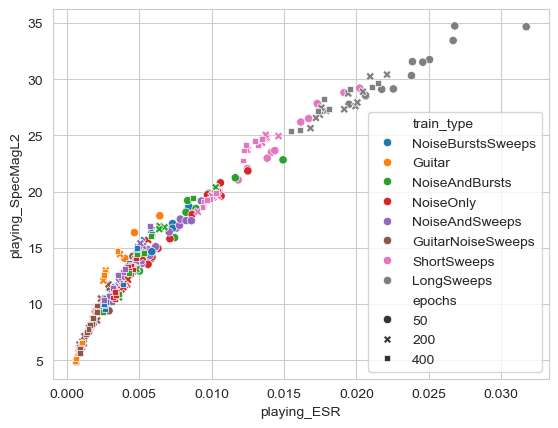

In [8775]:
sns.scatterplot(data=df, x="playing_ESR", 
                y="playing_SpecMagL2", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

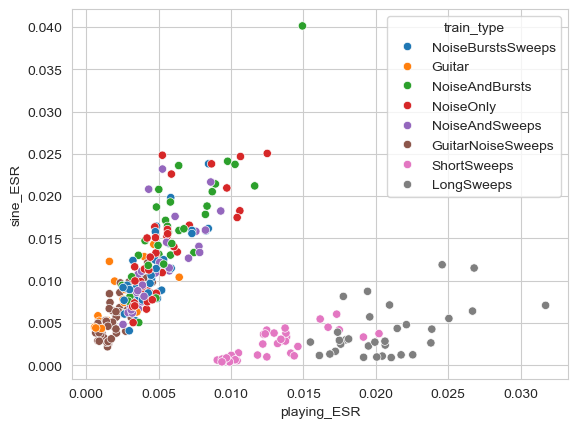

In [8776]:
sns.scatterplot(data=df, x="playing_ESR", y="sine_ESR", hue='train_type')

# Show the plot
plt.show()

In [8777]:
df.train_type.unique()

array(['NoiseBurstsSweeps', 'Guitar', 'NoiseAndBursts', 'NoiseOnly',
       'NoiseAndSweeps', 'GuitarNoiseSweeps', 'ShortSweeps', 'LongSweeps'],
      dtype=object)

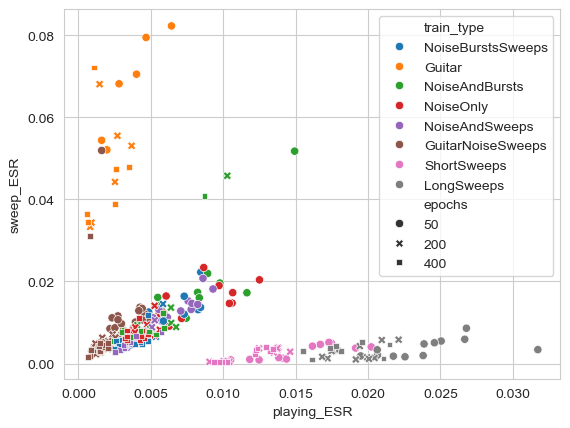

In [8778]:
sns.scatterplot(data=df, x="playing_ESR", 
                y="sweep_ESR", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

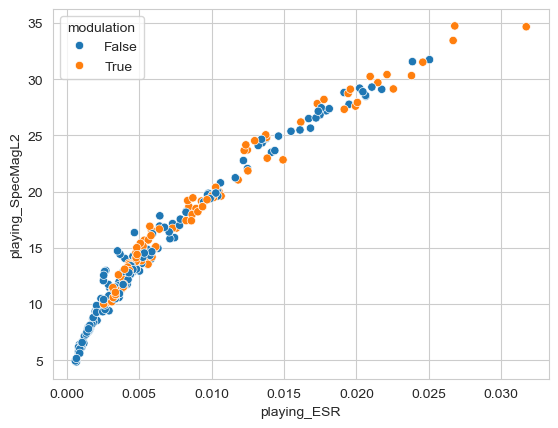

In [8779]:
sns.scatterplot(data=df, x="playing_ESR", y="playing_SpecMagL2", hue='modulation')

# Show the plot
plt.show()

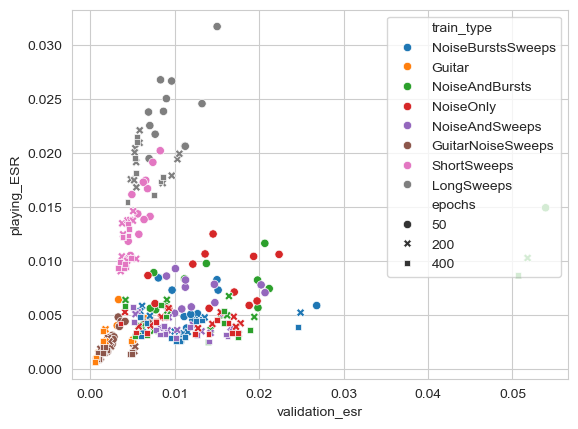

In [8780]:
sns.scatterplot(data=df, x="validation_esr", 
                y="playing_ESR", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

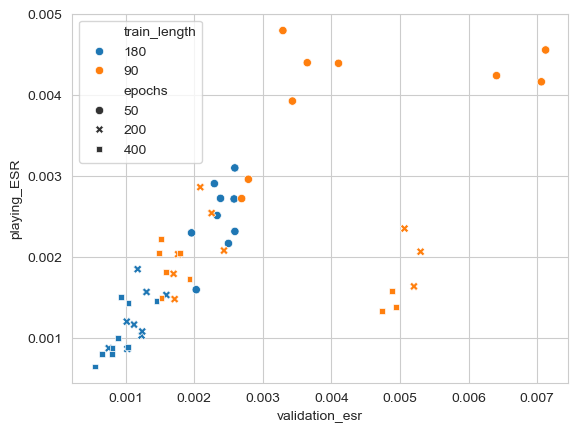

In [8781]:
sns.scatterplot(data=df[df.train_type=='GuitarNoiseSweeps'], x="validation_esr", 
                y="playing_ESR", 
                hue='train_length',
                style='epochs')

# Show the plot
plt.show()

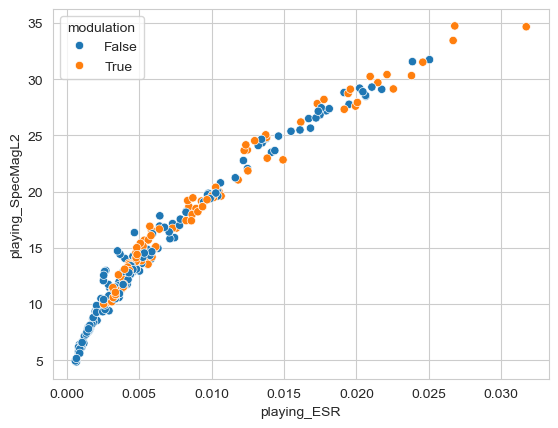

In [8782]:
sns.scatterplot(data=df, x="playing_ESR", y="playing_SpecMagL2", hue='modulation')

# Show the plot
plt.show()

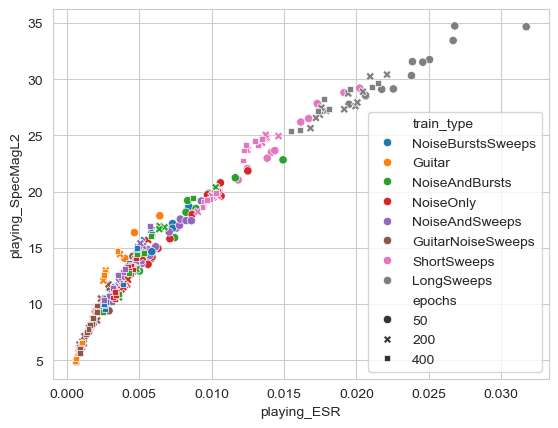

In [8783]:
sns.scatterplot(data=df, 
                x="playing_ESR", 
                y="playing_SpecMagL2", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

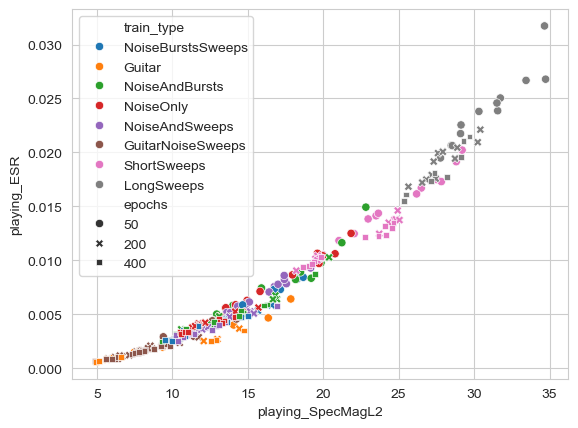

In [8784]:
sns.scatterplot(data=df, 
                x="playing_SpecMagL2", 
                y="playing_ESR", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

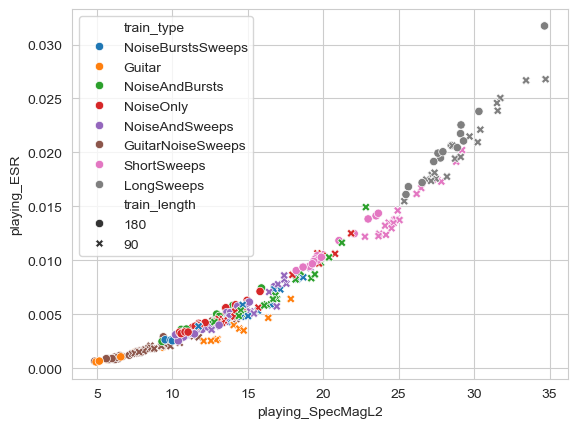

In [8785]:
sns.scatterplot(data=df, 
                x="playing_SpecMagL2", 
                y="playing_ESR", 
                hue='train_type',
                style='train_length')

# Show the plot
plt.show()

In [8786]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

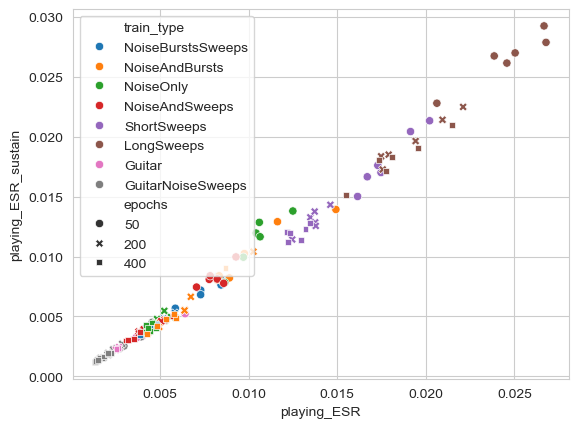

In [8787]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_ESR", 
                y="playing_ESR_sustain", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

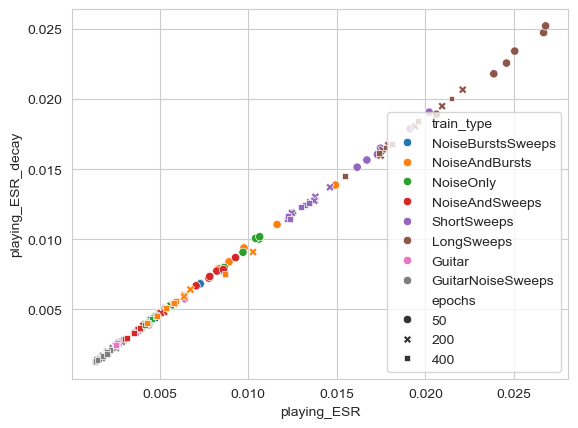

In [8788]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_ESR", 
                y="playing_ESR_decay", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

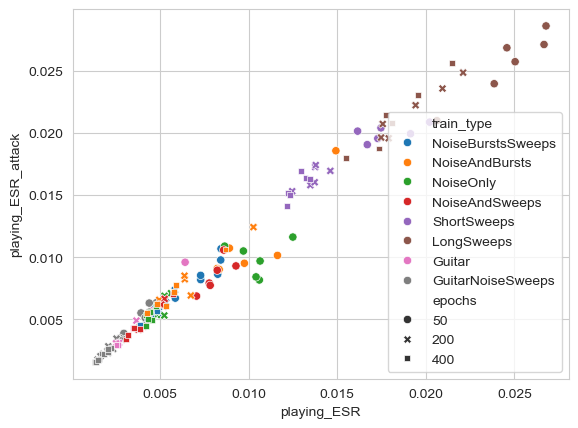

In [8789]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_ESR", 
                y="playing_ESR_attack", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

In [8790]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

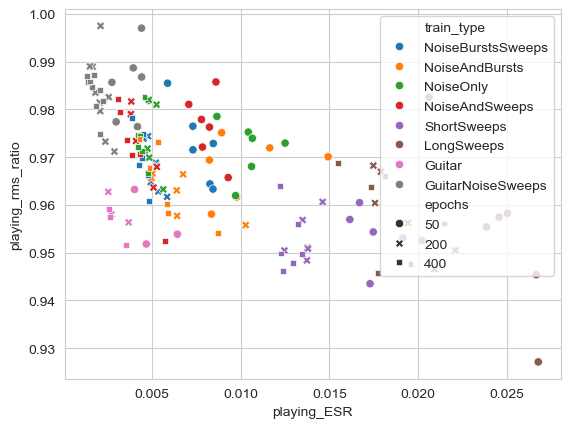

In [8791]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_ESR", 
                y="playing_rms_ratio", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

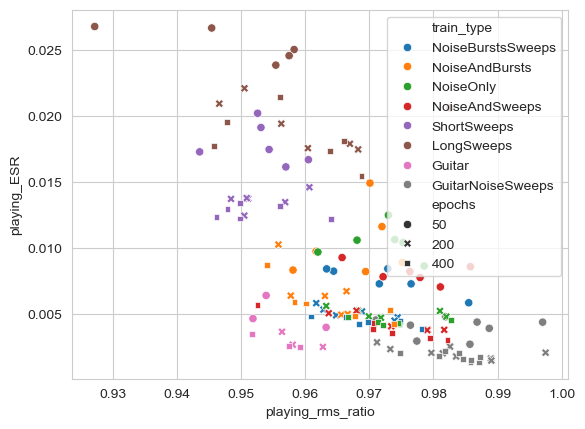

In [8792]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_rms_ratio", 
                y="playing_ESR", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

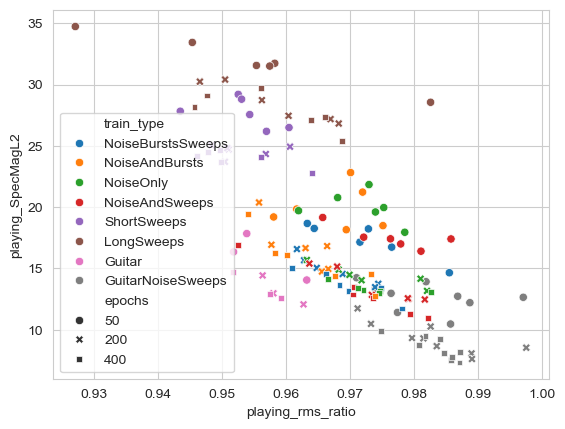

In [8793]:
sns.scatterplot(data=df[df.train_length=='90'], 
                x="playing_rms_ratio", 
                y="playing_SpecMagL2", 
                hue='train_type',
                style='epochs')

# Show the plot
plt.show()

In [8794]:
df_180 = df[df.train_length=='180']
df_90 = df[df.train_length=='90']

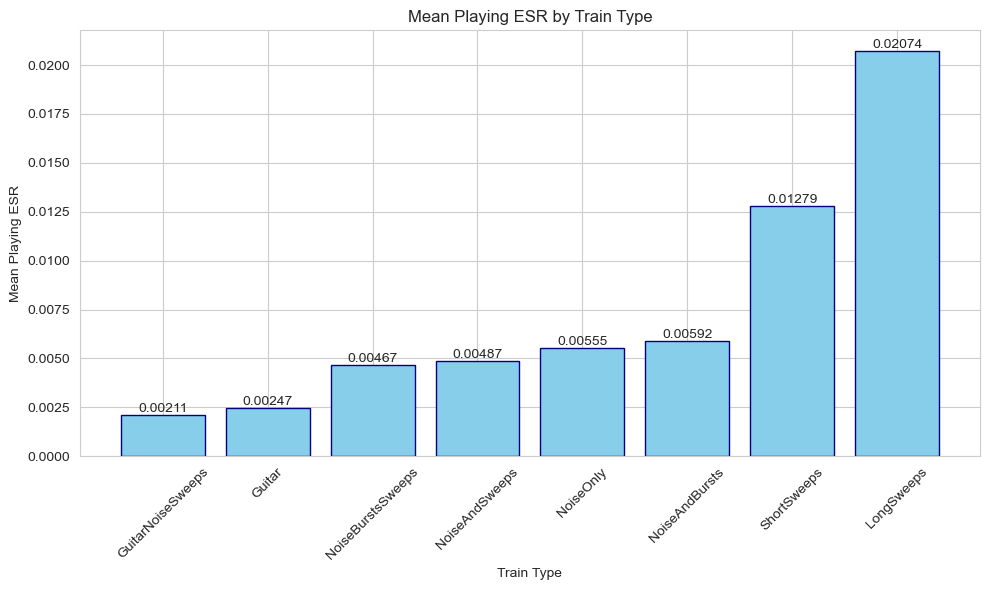

In [8795]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df.groupby('train_type')['playing_ESR'].mean().reset_index()
counts = df.groupby('train_type')['playing_ESR'].count().reset_index()

# 2. Sort the categories by the mean value (descending order)
mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['train_type'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Train Type')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Train Type')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('mean_playing_ESR_by_train_type.png')

In [8796]:
df.groupby(['train_type', 'train_length', 'epochs'])['playing_ESR'].describe().sort_values(by='mean')

count      mean       std       min  \
train_type        train_length epochs                                        
Guitar            180          400       3.0  0.000768  0.000252  0.000586   
GuitarNoiseSweeps 180          400       9.0  0.001052  0.000328  0.000653   
Guitar            180          200       3.0  0.001054  0.000353  0.000806   
GuitarNoiseSweeps 180          200       9.0  0.001247  0.000338  0.000871   
                  90           400       9.0  0.001745  0.000318  0.001341   
                               200       9.0  0.002100  0.000439  0.001486   
Guitar            180          50        3.0  0.002121  0.000618  0.001600   
GuitarNoiseSweeps 180          50        9.0  0.002488  0.000450  0.001602   
NoiseBurstsSweeps 180          400       6.0  0.002766  0.000193  0.002544   
Guitar            90           400       3.0  0.002886  0.000532  0.002547   
                               200       3.0  0.002962  0.000621  0.002521   
NoiseAndBursts    180          400       6.0  0.003049  0.000373  0.002480   
NoiseAndSweeps    180          400       6.0  0.003158  0.000480  0.002540   
NoiseBurstsSweeps 180          200       6.0  0.003256  0.000257  0.002763   
NoiseOnly         180          400       6.0  0.003306  0.000066  0.003208   
NoiseAndSweeps    180          200       6.0  0.003766  0.000519  0.003332   
NoiseAndBursts    180          200       6.0  0.003860  0.000557  0.003207   
NoiseAndSweeps    90           400       6.0  0.003957  0.000982  0.003068   
NoiseOnly         180          200       6.0  0.004000  0.000170  0.003770   
GuitarNoiseSweeps 90           50        9.0  0.004023  0.000712  0.002727   
NoiseAndSweeps    90           200       6.0  0.004310  0.000677  0.003792   
NoiseOnly         90           400       6.0  0.004419  0.000223  0.004200   
NoiseBurstsSweeps 90           400       6.0  0.004444  0.000346  0.003886   
                  180          50        6.0  0.004844  0.000648  0.003781   
Guitar            90           50        3.0  0.005031  0.001248  0.004006   
NoiseOnly         90           200       6.0  0.005085  0.000348  0.004736   
NoiseBurstsSweeps 90           200       6.0  0.005098  0.000470  0.004514   
NoiseAndBursts    90           400       6.0  0.005818  0.001539  0.004284   
                  180          50        6.0  0.005838  0.000830  0.005018   
NoiseAndSweeps    180          50        6.0  0.005888  0.000902  0.005159   
NoiseOnly         180          50        6.0  0.006088  0.000573  0.005574   
NoiseAndBursts    90           200       6.0  0.006631  0.001940  0.004959   
NoiseBurstsSweeps 90           50        6.0  0.007601  0.001003  0.005867   
NoiseAndSweeps    90           50        6.0  0.008134  0.000764  0.007066   
ShortSweeps       180          400       6.0  0.009678  0.000361  0.009371   
                               200       6.0  0.010006  0.000487  0.009049   
NoiseAndBursts    90           50        6.0  0.010304  0.002589  0.008230   
NoiseOnly         90           50        6.0  0.010424  0.001269  0.008652   
ShortSweeps       90           400       6.0  0.012739  0.000541  0.012194   
                  180          50        6.0  0.012857  0.001519  0.010512   
                  90           200       6.0  0.013643  0.000694  0.012465   
                               50        6.0  0.017832  0.001544  0.016156   
LongSweeps        90           400       6.0  0.018296  0.002044  0.015480   
                  180          400       2.0  0.018583  0.003508  0.016102   
                               200       6.0  0.018938  0.001552  0.016826   
                  90           200       6.0  0.019241  0.001941  0.017481   
                  180          50        6.0  0.023326  0.004376  0.019488   
                  90           50        6.0  0.024597  0.002263  0.020629   

                                            25%       50%       75%       max  
train_type        train_length epochs                     

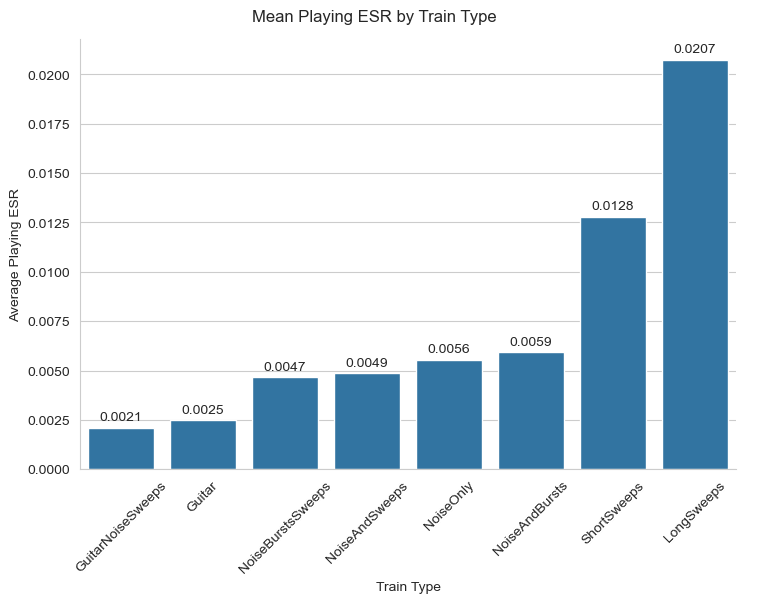

In [8797]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_ESR', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Type", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_type.png')
plt.show()


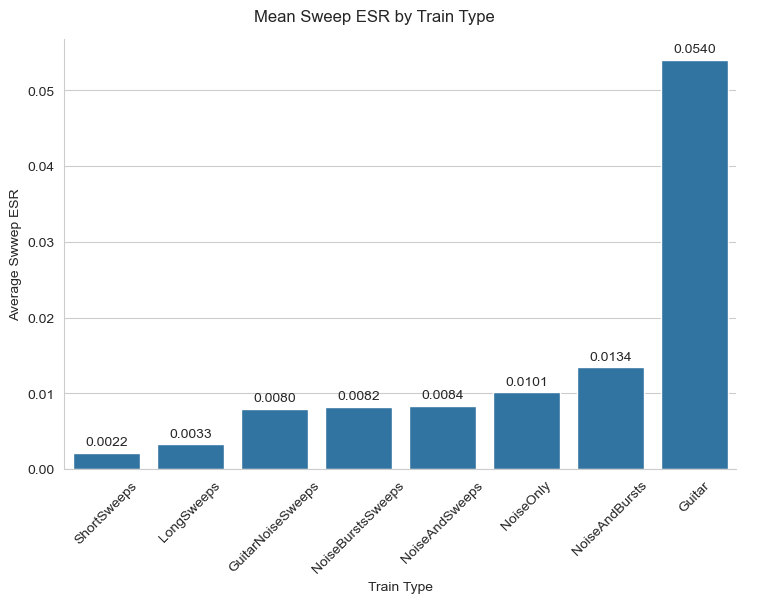

In [8798]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['sweep_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='sweep_ESR', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average Swwep ESR")
g.fig.suptitle("Mean Sweep ESR by Train Type", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_sweep_ESR_by_train_type.png')
plt.show()


In [8799]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

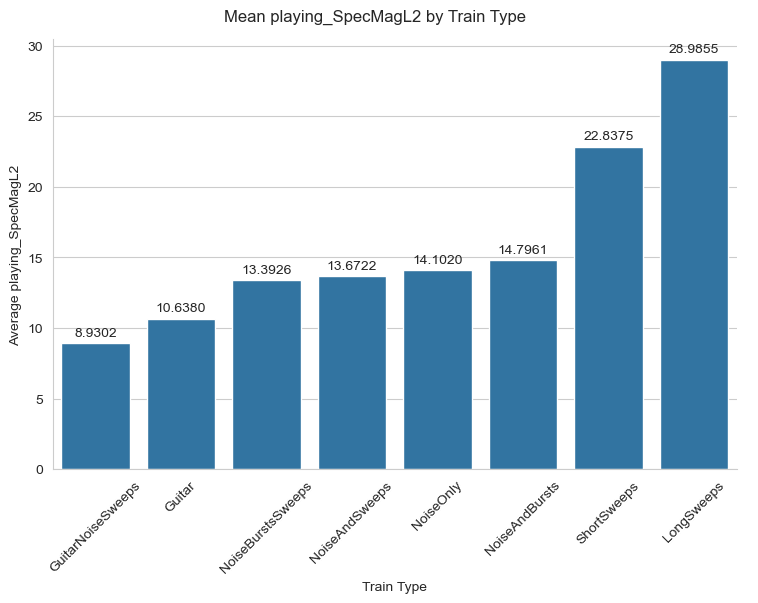

In [8800]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_SpecMagL2'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_SpecMagL2', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average playing_SpecMagL2")
g.fig.suptitle("Mean playing_SpecMagL2 by Train Type", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_SpecMagL2_by_train_type.png')
plt.show()


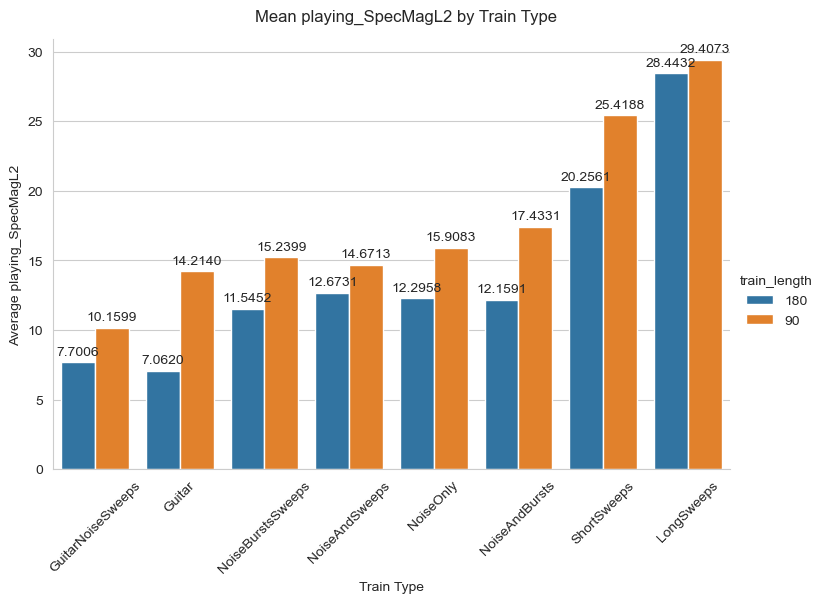

In [8801]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_SpecMagL2'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_SpecMagL2', 
    hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average playing_SpecMagL2")
g.fig.suptitle("Mean playing_SpecMagL2 by Train Type", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_SpecMagL2_by_train_type.png')
plt.show()


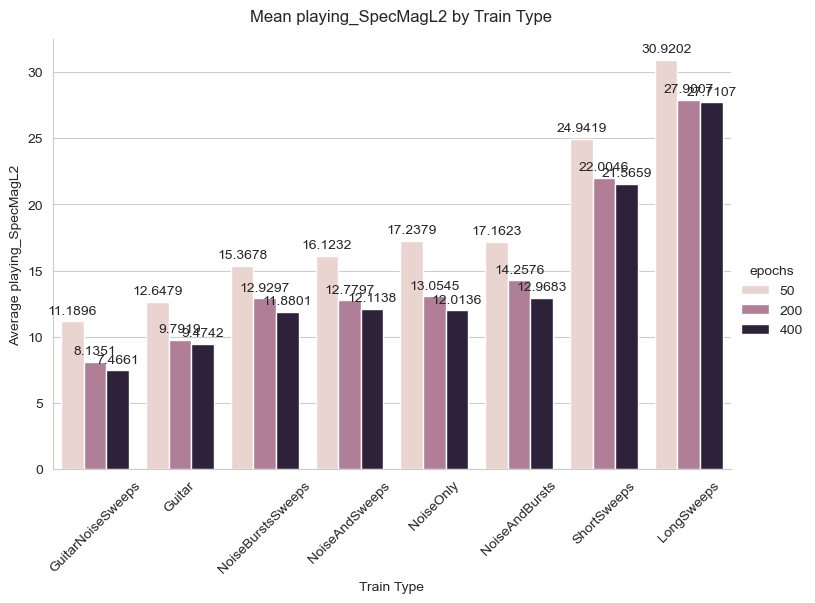

In [8802]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_SpecMagL2'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_SpecMagL2', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average playing_SpecMagL2")
g.fig.suptitle("Mean playing_SpecMagL2 by Train Type", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_SpecMagL2_by_train_type.png')
plt.show()


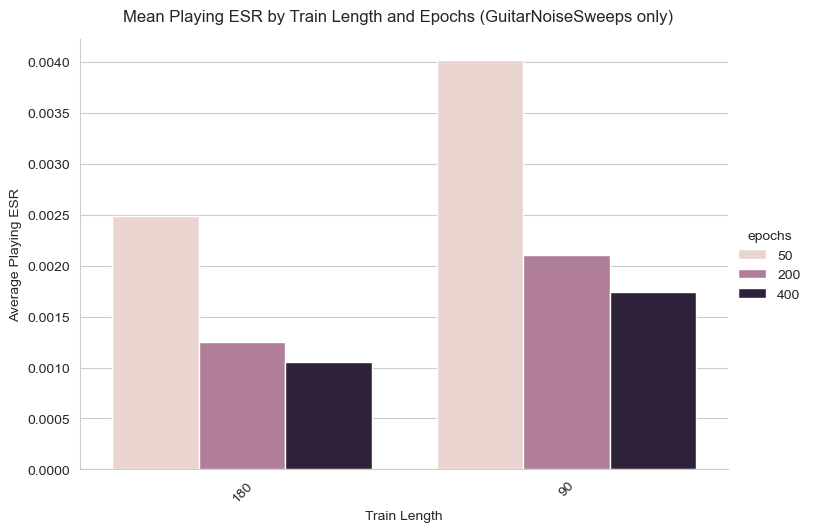

In [8803]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df[df.train_type=='GuitarNoiseSweeps'].groupby('train_length')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df[df.train_type=='GuitarNoiseSweeps'], 
    x='train_length', 
    y='playing_ESR', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

g.set_axis_labels("Train Length", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Length and Epochs (GuitarNoiseSweeps only)", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_length_and_epochs_RNS.png')
plt.show()


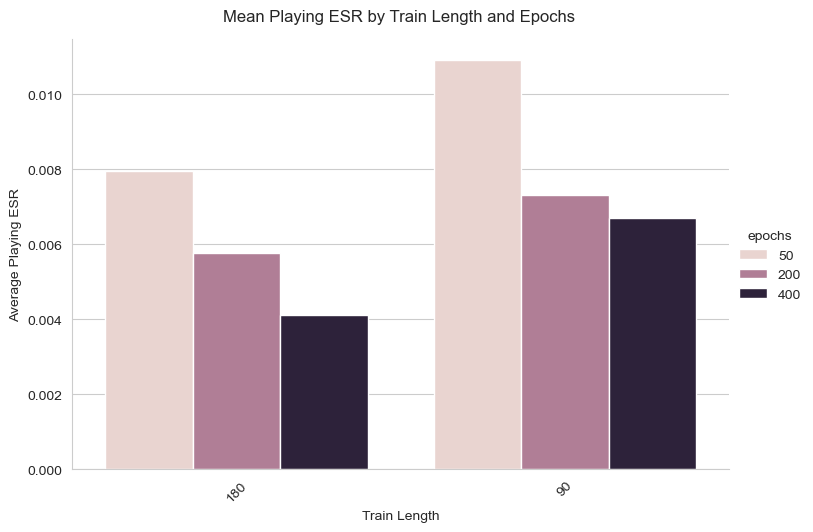

In [8804]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df[df.train_type=='GuitarNoiseSweeps'].groupby('train_length')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_length', 
    y='playing_ESR', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

g.set_axis_labels("Train Length", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Length and Epochs", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_length_and_epochs_RNS2.png')
plt.show()


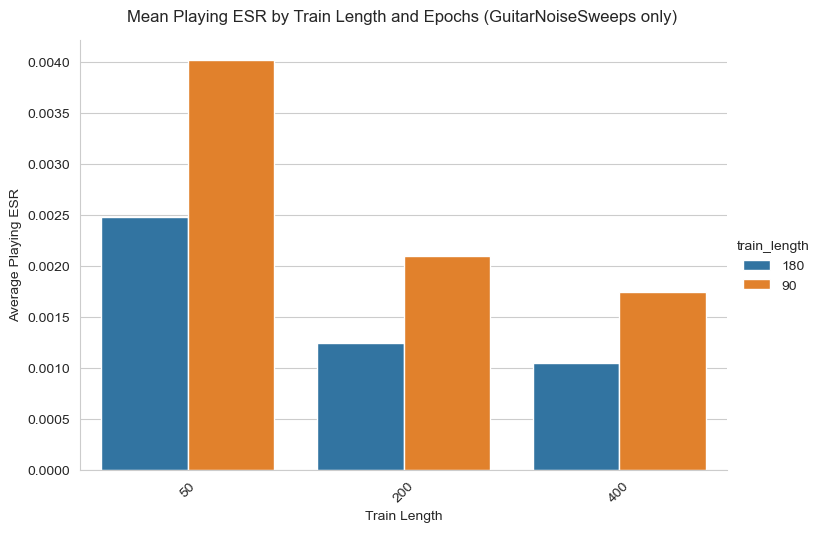

In [8805]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df[df.train_type=='GuitarNoiseSweeps'].groupby('train_length')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df[df.train_type=='GuitarNoiseSweeps'], 
    x='epochs', 
    y='playing_ESR', 
    hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

g.set_axis_labels("Train Length", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Length and Epochs (GuitarNoiseSweeps only)", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_length_and_epochs_RNS.png')
plt.show()


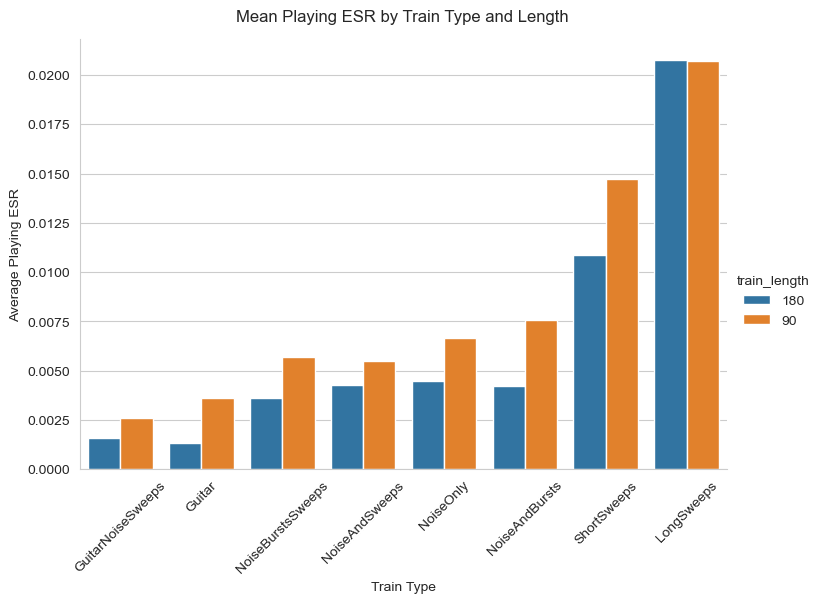

In [8806]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_ESR', 
    hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Type and Length", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_type_and_length.png')
plt.show()


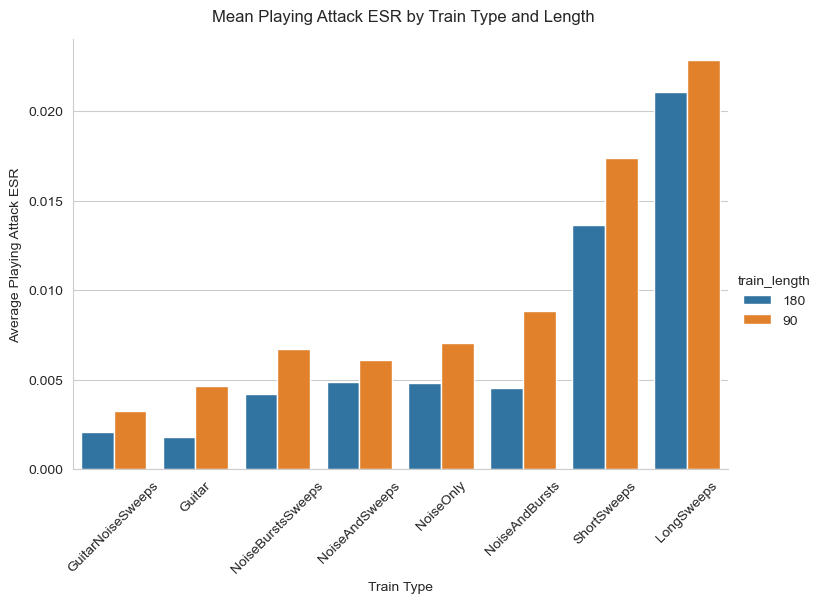

In [8807]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_ESR_attack', 
    hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

g.set_axis_labels("Train Type", "Average Playing Attack ESR")
g.fig.suptitle("Mean Playing Attack ESR by Train Type and Length", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_attack_ESR_by_train_type_and_length.png')
plt.show()


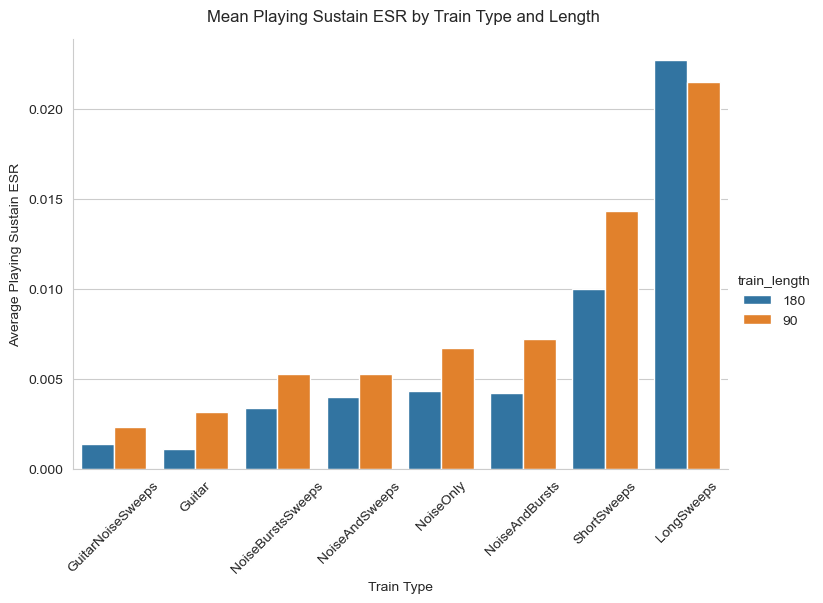

In [8808]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_ESR_sustain', 
    hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

g.set_axis_labels("Train Type", "Average Playing Sustain ESR")
g.fig.suptitle("Mean Playing Sustain ESR by Train Type and Length", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_sustain_ESR_by_train_type_and_length.png')
plt.show()


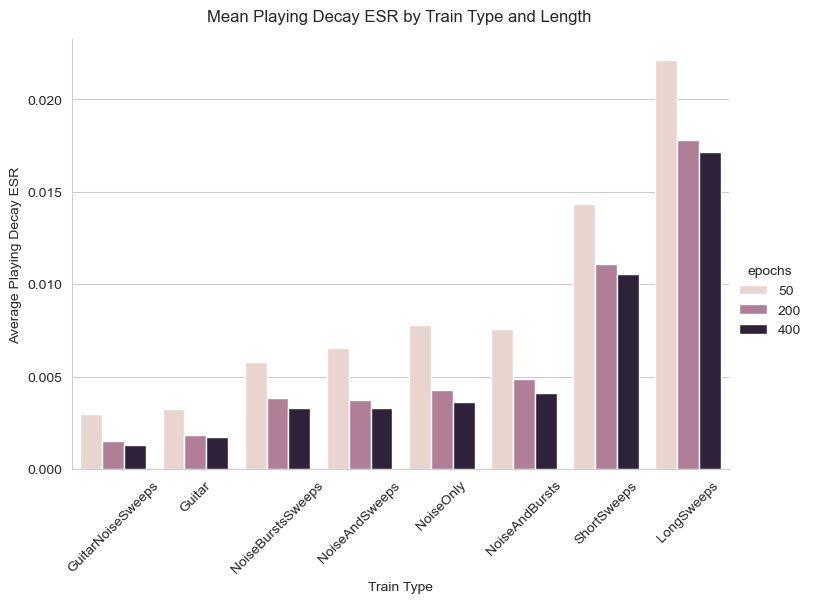

In [8809]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df.groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='train_type', 
    y='playing_ESR_decay', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

g.set_axis_labels("Train Type", "Average Playing Decay ESR")
g.fig.suptitle("Mean Playing Decay ESR by Train Type and Length", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_decay_ESR_by_train_type_and_length.png')
plt.show()


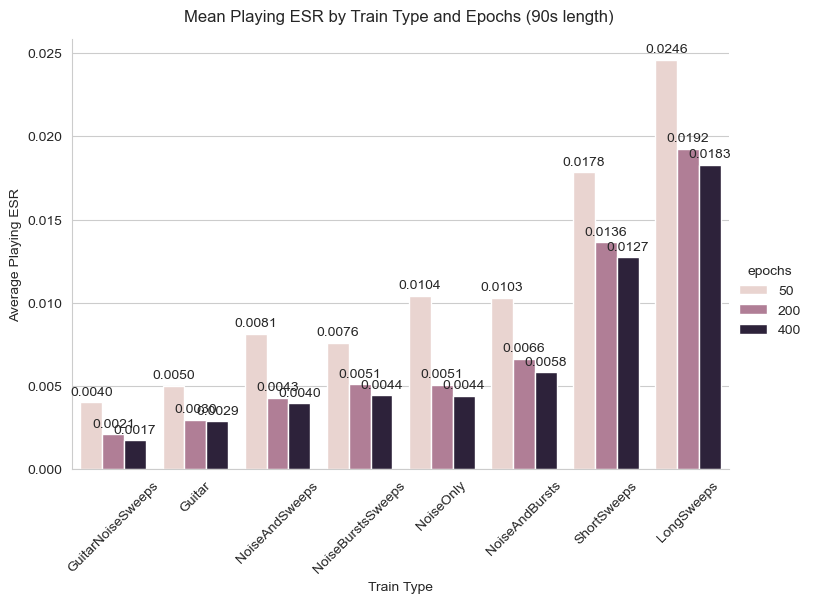

In [8810]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df[df.train_length=='90'].groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df[df.train_length=='90'], 
    x='train_type', 
    y='playing_ESR', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Type and Epochs (90s length)", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_type_and_epochs.png')
plt.show()


In [8811]:
df[df.train_length=='90'].groupby(['train_type', 'epochs'])['playing_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        epochs                                                  
GuitarNoiseSweeps 400       9.0  0.001745  0.000318  0.001341  0.001498   
                  200       9.0  0.002100  0.000439  0.001486  0.001798   
Guitar            400       3.0  0.002886  0.000532  0.002547  0.002579   
                  200       3.0  0.002962  0.000621  0.002521  0.002607   
NoiseAndSweeps    400       6.0  0.003957  0.000982  0.003068  0.003278   
GuitarNoiseSweeps 50        9.0  0.004023  0.000712  0.002727  0.003931   
NoiseAndSweeps    200       6.0  0.004310  0.000677  0.003792  0.003820   
NoiseOnly         400       6.0  0.004419  0.000223  0.004200  0.004247   
NoiseBurstsSweeps 400       6.0  0.004444  0.000346  0.003886  0.004313   
Guitar            50        3.0  0.005031  0.001248  0.004006  0.004336   
NoiseOnly         200       6.0  0.005085  0.000348  0.004736  0.004819   
NoiseBurstsSweeps 200       6.0  0.005098  0.000470  0.004514  0.004805   
NoiseAndBursts    400       6.0  0.005818  0.001539  0.004284  0.004974   
                  200       6.0  0.006631  0.001940  0.004959  0.005356   
NoiseBurstsSweeps 50        6.0  0.007601  0.001003  0.005867  0.007299   
NoiseAndSweeps    50        6.0  0.008134  0.000764  0.007066  0.007796   
NoiseAndBursts    50        6.0  0.010304  0.002589  0.008230  0.008488   
NoiseOnly         50        6.0  0.010424  0.001269  0.008652  0.009888   
ShortSweeps       400       6.0  0.012739  0.000541  0.012194  0.012274   
                  200       6.0  0.013643  0.000694  0.012465  0.013549   
                  50        6.0  0.017832  0.001544  0.016156  0.016850   
LongSweeps        400       6.0  0.018296  0.002044  0.015480  0.017460   
                  200       6.0  0.019241  0.001941  0.017481  0.017657   
                  50        6.0  0.024597  0.002263  0.020629  0.024043   

                               50%       75%       max  
train_type        epochs                                
GuitarNoiseSweeps 400     0.001731  0.002053  0.002232  
                  200     0.002071  0.002357  0.002868  
Guitar            400     0.002611  0.003055  0.003499  
                  200     0.002692  0.003182  0.003672  
NoiseAndSweeps    400     0.003722  0.004206  0.005730  
GuitarNoiseSweeps 50      0.004245  0.004405  0.004802  
NoiseAndSweeps    200     0.003956  0.004827  0.005263  
NoiseOnly         400     0.004372  0.004528  0.004783  
NoiseBurstsSweeps 400     0.004446  0.004700  0.004830  
Guitar            50      0.004667  0.005544  0.006421  
NoiseOnly         200     0.005040  0.005255  0.005624  
NoiseBurstsSweeps 200     0.005062  0.005311  0.005839  
NoiseAndBursts    400     0.005582  0.005886  0.008703  
                  200     0.006395  0.006659  0.010276  
NoiseBurstsSweeps 50      0.007781  0.008389  0.008448  
NoiseAndSweeps    50      0.008035  0.008507  0.009290  
NoiseAndBursts    50      0.009343  0.011167  0.014930  
NoiseOnly         50      0.010516  0.010641  0.012501  
ShortSweeps       400     0.012666  0.013154  0.013446  
                  200     0.013747  0.013785  0.014618  
                  50      0.017385  0.018725  0.020219  
LongSweeps        400     0.017939  0.019215  0.021477  
                  200     0.018668  0.020567  0.022110  
                  50      0.024812  0.026269  0.026788

### Sorted by std:

In [8812]:
df[df.train_length=='90'].groupby(['train_type', 'epochs'])['playing_ESR'].describe().sort_values(by='std')

,,count,mean,std,min,25%,50%,75%,max
train_type,epochs,,,,,,,,
NoiseOnly,400,6.0,0.004419,0.000223,0.004200,0.004247,0.004372,0.004528,0.004783
GuitarNoiseSweeps,400,9.0,0.001745,0.000318,0.001341,0.001498,0.001731,0.002053,0.002232
NoiseBurstsSweeps,400,6.0,0.004444,0.000346,0.003886,0.004313,0.004446,0.004700,0.004830
NoiseOnly,200,6.0,0.005085,0.000348,0.004736,0.004819,0.005040,0.005255,0.005624
GuitarNoiseSweeps,200,9.0,0.002100,0.000439,0.001486,0.001798,0.002071,0.002357,0.002868
NoiseBurstsSweeps,200,6.0,0.005098,0.000470,0.004514,0.004805,0.005062,0.005311,0.005839
Guitar,400,3.0,0.002886,0.000532,0.002547,0.002579,0.002611,0.003055,0.003499
ShortSweeps,400,6.0,0.012739,0.000541,0.012194,0.012274,0.012666,0.013154,0.013446
Guitar,200,3.0,0.002962,0.000621,0.002521,0.002607,0.002692,0.003182,0.003672


In [8813]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

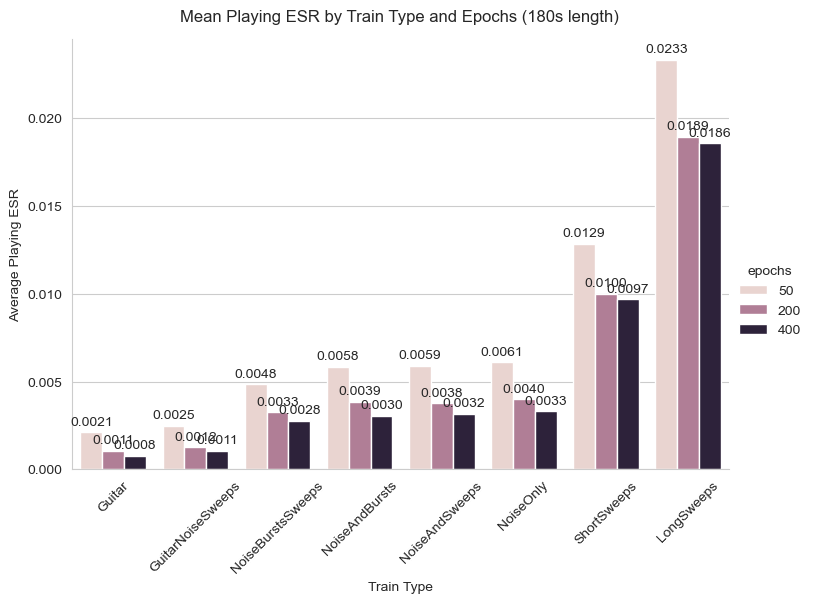

In [8814]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df[df.train_length=='180'].groupby('train_type')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df[df.train_length=='180'], 
    x='train_type', 
    y='playing_ESR', 
    hue='epochs', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Train Type and Epochs (180s length)", y=1.03)
plt.xticks(rotation=45)
plt.savefig('mean_playing_ESR_by_train_type_and_epochs.png')
plt.show()


In [8815]:
df[df.train_length=='180'].groupby(['train_type', 'epochs'])['playing_ESR'].describe().sort_values(by='mean')

,,count,mean,std,min,25%,50%,75%,max
train_type,epochs,,,,,,,,
Guitar,400,3.0,0.000768,0.000252,0.000586,0.000624,0.000662,0.000859,0.001056
GuitarNoiseSweeps,400,9.0,0.001052,0.000328,0.000653,0.000809,0.000897,0.001435,0.001512
Guitar,200,3.0,0.001054,0.000353,0.000806,0.000852,0.000898,0.001178,0.001459
GuitarNoiseSweeps,200,9.0,0.001247,0.000338,0.000871,0.001036,0.001172,0.001537,0.001856
Guitar,50,3.0,0.002121,0.000618,0.001600,0.001779,0.001959,0.002382,0.002804
GuitarNoiseSweeps,50,9.0,0.002488,0.000450,0.001602,0.002304,0.002518,0.002730,0.003106
NoiseBurstsSweeps,400,6.0,0.002766,0.000193,0.002544,0.002622,0.002733,0.002936,0.002996
NoiseAndBursts,400,6.0,0.003049,0.000373,0.002480,0.002941,0.003063,0.003132,0.003632
NoiseAndSweeps,400,6.0,0.003158,0.000480,0.002540,0.002949,0.003144,0.003216,0.003992


In [8816]:
df[df.train_length=='180'].groupby(['train_type', 'epochs'])['sweep_ESR'].describe().sort_values(by='mean')

count      mean       std       min       25%  \
train_type        epochs                                                  
ShortSweeps       400       6.0  0.000450  0.000032  0.000400  0.000430   
                  200       6.0  0.000512  0.000077  0.000417  0.000449   
                  50        6.0  0.001111  0.000224  0.000897  0.000927   
LongSweeps        400       2.0  0.001118  0.000172  0.000997  0.001057   
                  200       6.0  0.001323  0.000238  0.000999  0.001175   
                  50        6.0  0.002125  0.000638  0.001653  0.001818   
NoiseAndSweeps    400       6.0  0.004281  0.001391  0.002808  0.003382   
NoiseBurstsSweeps 400       6.0  0.004356  0.001004  0.003471  0.003582   
                  200       6.0  0.005014  0.000744  0.004174  0.004560   
NoiseAndSweeps    200       6.0  0.005412  0.001120  0.003921  0.004726   
GuitarNoiseSweeps 400       9.0  0.005944  0.009440  0.001696  0.002809   
NoiseOnly         400       6.0  0.006471  0.000825  0.005711  0.006121   
NoiseAndBursts    400       6.0  0.006573  0.001122  0.005551  0.005730   
GuitarNoiseSweeps 200       9.0  0.006986  0.010225  0.002291  0.002715   
NoiseOnly         200       6.0  0.007630  0.000726  0.006886  0.007105   
NoiseAndBursts    200       6.0  0.007633  0.001018  0.006739  0.006901   
NoiseBurstsSweeps 50        6.0  0.010522  0.002527  0.007153  0.008986   
NoiseAndSweeps    50        6.0  0.011379  0.002752  0.007089  0.010543   
NoiseOnly         50        6.0  0.012064  0.002433  0.009138  0.011066   
NoiseAndBursts    50        6.0  0.012571  0.002227  0.010147  0.011118   
GuitarNoiseSweeps 50        9.0  0.013225  0.014644  0.005821  0.006861   
Guitar            200       3.0  0.045238  0.019774  0.033293  0.033825   
                  400       3.0  0.047666  0.021205  0.034418  0.035437   
                  50        3.0  0.058206  0.008699  0.052069  0.053228   

                               50%       75%       max  
train_type        epochs                                
ShortSweeps       400     0.000462  0.000474  0.000477  
                  200     0.000524  0.000565  0.000604  
                  50      0.001060  0.001256  0.001445  
LongSweeps        400     0.001118  0.001179  0.001240  
                  200     0.001321  0.001476  0.001646  
                  50      0.001906  0.002052  0.003394  
NoiseAndSweeps    400     0.004164  0.004553  0.006744  
NoiseBurstsSweeps 400     0.003966  0.005112  0.005788  
                  200     0.004850  0.005358  0.006222  
NoiseAndSweeps    200     0.005317  0.006349  0.006693  
GuitarNoiseSweeps 400     0.003166  0.003355  0.031065  
NoiseOnly         400     0.006175  0.006501  0.008055  
NoiseAndBursts    400     0.006156  0.007358  0.008230  
GuitarNoiseSweeps 200     0.003758  0.004905  0.034124  
NoiseOnly         200     0.007492  0.007949  0.008832  
NoiseAndBursts    200     0.007281  0.008094  0.009359  
NoiseBurstsSweeps 50      0.010384  0.012063  0.014070  
NoiseAndSweeps    50      0.011199  0.012698  0.015266  
NoiseOnly         50      0.011759  0.012270  0.016449  
NoiseAndBursts    50      0.011985  0.013772  0.016113  
GuitarNoiseSweeps 50      0.008507  0.011139  0.051916  
Guitar            200     0.034357  0.051210  0.068063  
                  400     0.036457  0.054290  0.072123  
                  50      0.054387  0.061274  0.068162

In [8817]:
df_synth

,train_label,validation_esr,seed,epochs,latency,model_type,sine_shift_samples,sine_shift_ms,sine_ESR,sine_RMSE,...,playing_frac_attack,playing_frac_sustain,playing_frac_decay,train_type,amp_type,train_length,modulation,seed/version,playing_rms_ratio,sweep
0,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.011392,0,50,525,WaveNet,-531,-11.0625,0.010720,0.024739,...,0.075092,0.341744,0.433164,NoiseBurstsSweeps,clean,180,False,1,1.000466,noise
1,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.012140,0,50,525,WaveNet,-531,-11.0625,0.011214,0.025303,...,0.075092,0.341744,0.433164,NoiseBurstsSweeps,clean,180,False,2,1.007567,noise
2,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.011100,0,50,525,WaveNet,-531,-11.0625,0.016443,0.030639,...,0.075092,0.341744,0.433164,NoiseBurstsSweeps,clean,180,True,1,1.005202,noise
3,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.007688,0,50,525,WaveNet,-531,-11.0625,0.014392,0.028665,...,0.075092,0.341744,0.433164,NoiseBurstsSweeps,clean,180,True,2,0.995759,noise
4,TrainingFiles/NEW_clean_NBS/clean_NBS_180_shor...,0.012696,0,50,525,WaveNet,-531,-11.0625,0.008787,0.022398,...,0.075092,0.341744,0.433164,NoiseBurstsSweeps,clean,180,False,3,1.019706,noise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,0.004389,0,400,532,WaveNet,-531,-11.0625,0.002742,0.012512,...,0.075092,0.341744,0.433164,LongSweeps,clean,90,False,2,0.968765,sweep
251,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,0.005422,0,400,532,WaveNet,-531,-11.0625,0.003109,0.013322,...,0.075092,0.341744,0.433164,LongSweeps,clean,90,False,3,0.966075,sweep
252,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,0.008607,0,400,532,WaveNet,-531,-11.0625,0.008142,0.021560,...,0.075092,0.341744,0.433164,LongSweeps,clean,90,True,1,0.945737,sweep
253,TrainingFiles/NEW_clean_90s_longSweeps/clean_s...,0.005548,0,400,532,WaveNet,-531,-11.0625,0.004356,0.015770,...,0.075092,0.341744,0.433164,LongSweeps,clean,90,True,2,0.956118,sweep


# Modulation and Playing ESR

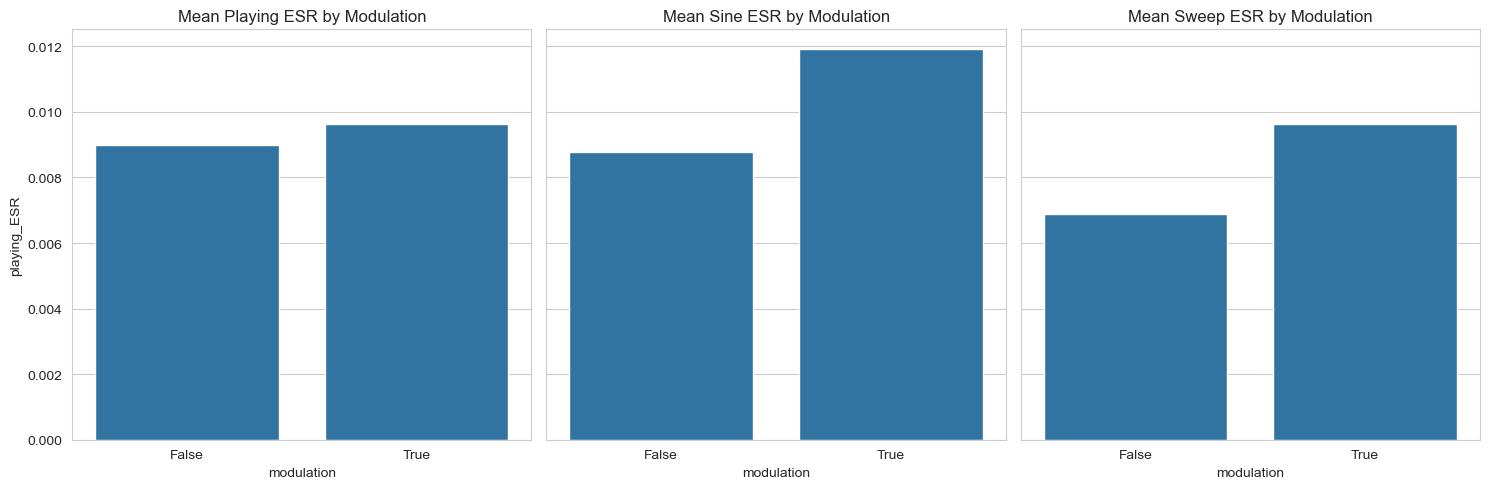

In [8818]:
# 1. Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

sns.barplot(ax=axes[0], 
            data=df_synth, 
            x="modulation", 
            y="playing_ESR",
            errorbar=None
           )

sns.barplot(ax=axes[1], 
            data=df_synth, 
            x="modulation", 
            y="sine_ESR",
            errorbar=None
           )

sns.barplot(ax=axes[2], 
            data=df_synth, 
            x="modulation", 
            y="sweep_ESR",
            errorbar=None
           )

axes[0].set_title('Mean Playing ESR by Modulation')
axes[1].set_title('Mean Sine ESR by Modulation')
axes[2].set_title('Mean Sweep ESR by Modulation')

plt.tight_layout()
plt.savefig('different_ESR_by_modulation.png')
plt.show()

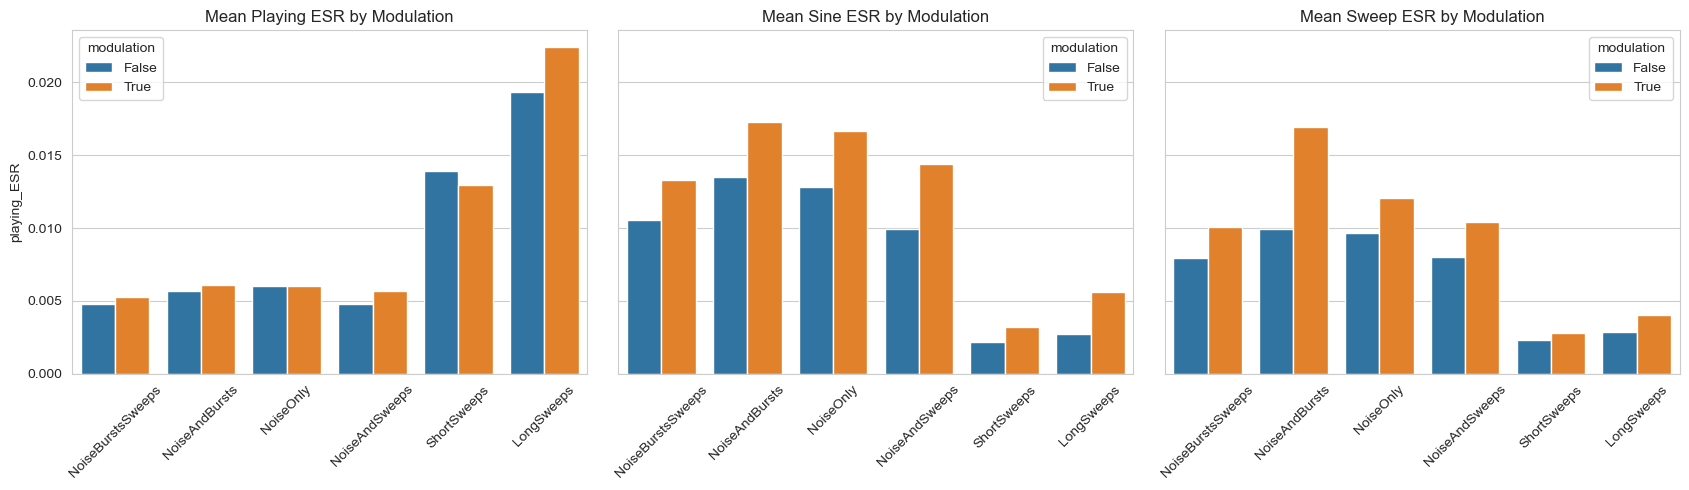

In [8819]:
# 1. Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

sns.barplot(ax=axes[0], 
            data=df_synth, 
            x="train_type", 
            y="playing_ESR",
            hue='modulation',
            errorbar=None
           )

sns.barplot(ax=axes[1], 
            data=df_synth, 
            x="train_type", 
            y="sine_ESR",
            hue='modulation',
            errorbar=None
           )

sns.barplot(ax=axes[2], 
            data=df_synth, 
            x="train_type", 
            y="sweep_ESR",
            hue='modulation',
            errorbar=None
           )

axes[0].set_title('Mean Playing ESR by Modulation')
axes[1].set_title('Mean Sine ESR by Modulation')
axes[2].set_title('Mean Sweep ESR by Modulation')
axes[0].tick_params(axis='x', labelrotation=45)
axes[1].tick_params(axis='x', labelrotation=45)
axes[2].tick_params(axis='x', labelrotation=45)
axes[0].set(xlabel=None)
axes[1].set(xlabel=None)
axes[2].set(xlabel=None)
plt.tight_layout()
plt.savefig('different_ESR_by_modulation.png')
plt.show()

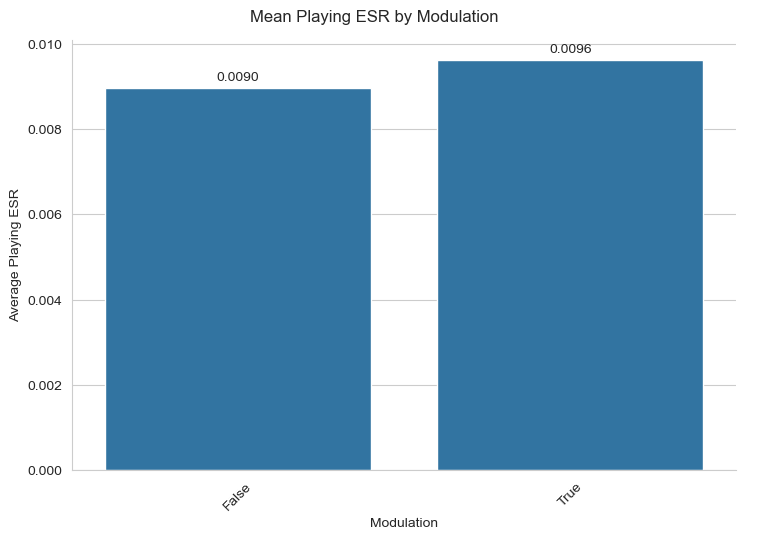

In [8820]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='modulation', 
    y='playing_ESR', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation", y=1.03)
plt.xticks(rotation=45)
plt.show()


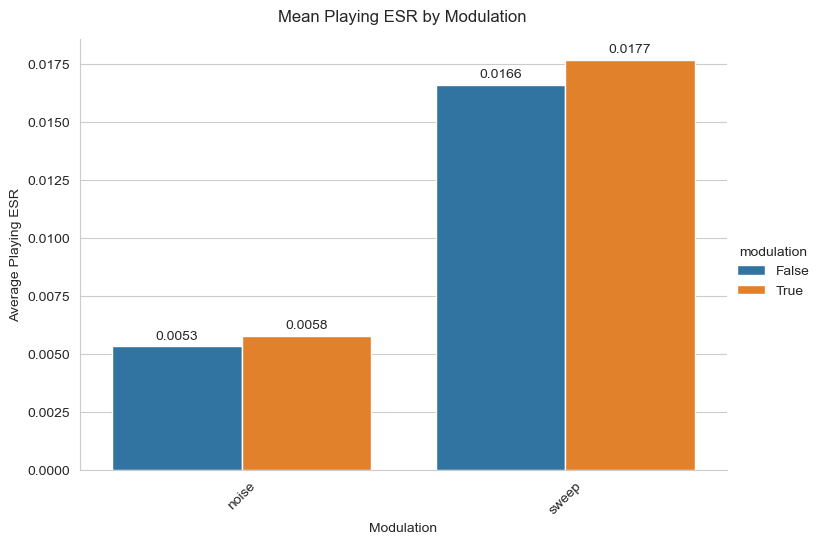

In [8821]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='sweep', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
   # order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation", y=1.03)
plt.xticks(rotation=45)
plt.show()


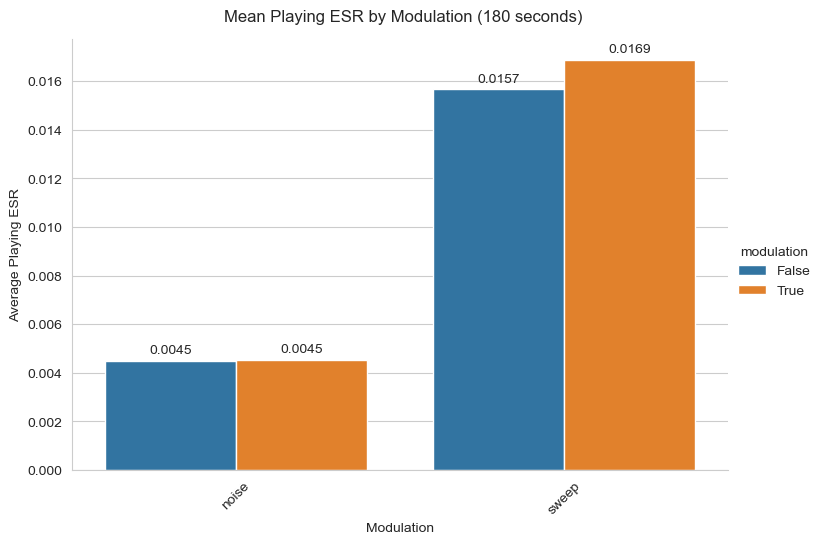

In [8822]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth[df_synth.train_length=='180'], 
    x='sweep', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
   # order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation (180 seconds)", y=1.03)
plt.xticks(rotation=45)
plt.show()


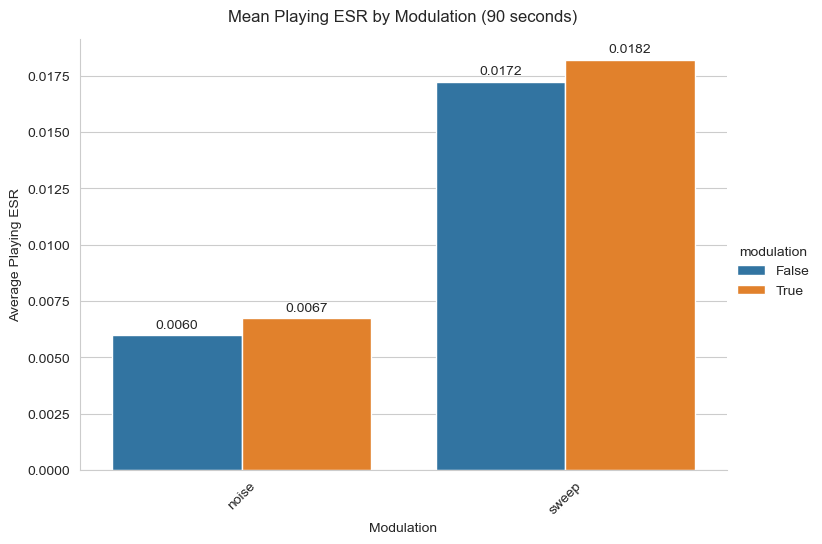

In [8823]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth[df_synth.train_length=='90'], 
    x='sweep', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
   # order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation (90 seconds)", y=1.03)
plt.xticks(rotation=45)
plt.show()


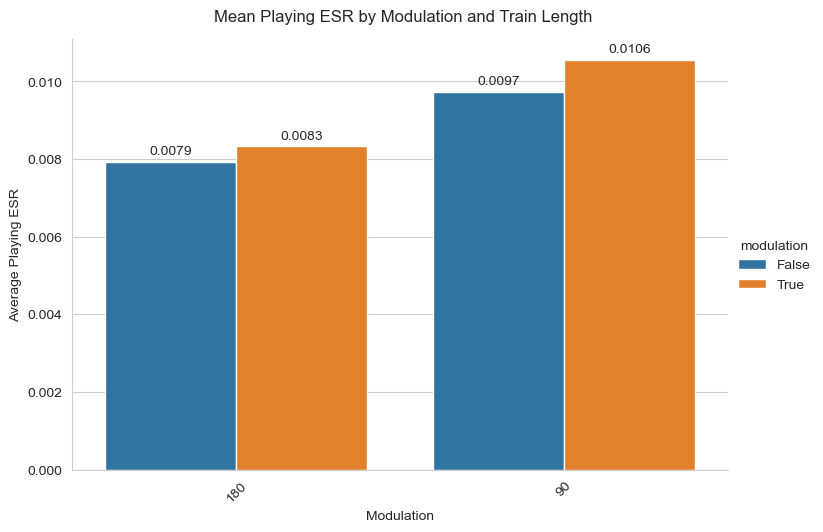

In [8824]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='train_length', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
#    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation and Train Length", y=1.03)
plt.xticks(rotation=45)
plt.show()


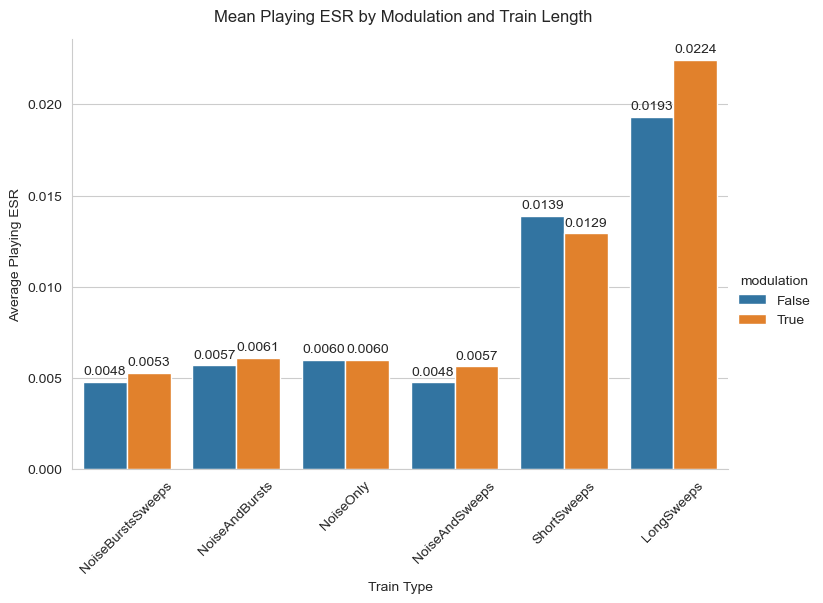

In [8825]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='train_type', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation and Train Length", y=1.03)
plt.xticks(rotation=45)
plt.show()


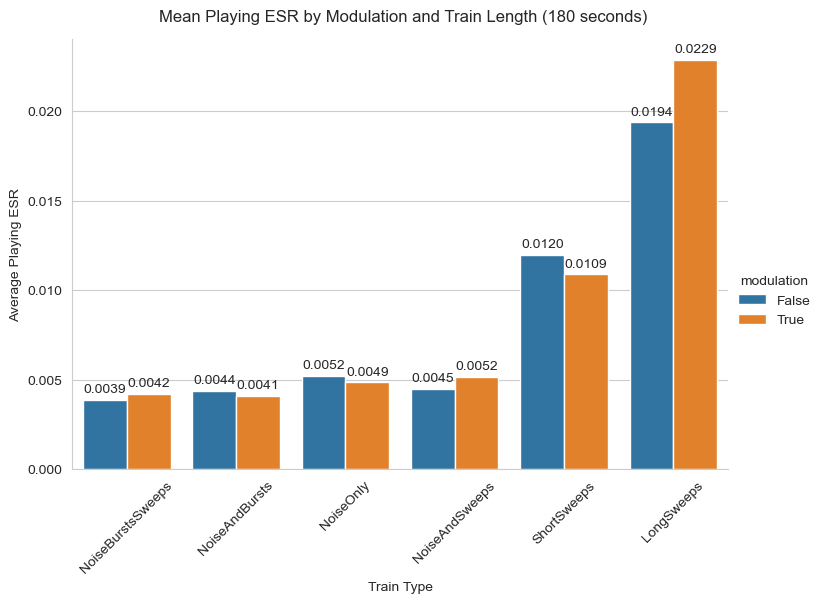

In [8826]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth[df_synth.train_length=='180'], 
    x='train_type', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation and Train Length (180 seconds)", y=1.03)
plt.xticks(rotation=45)
plt.show()


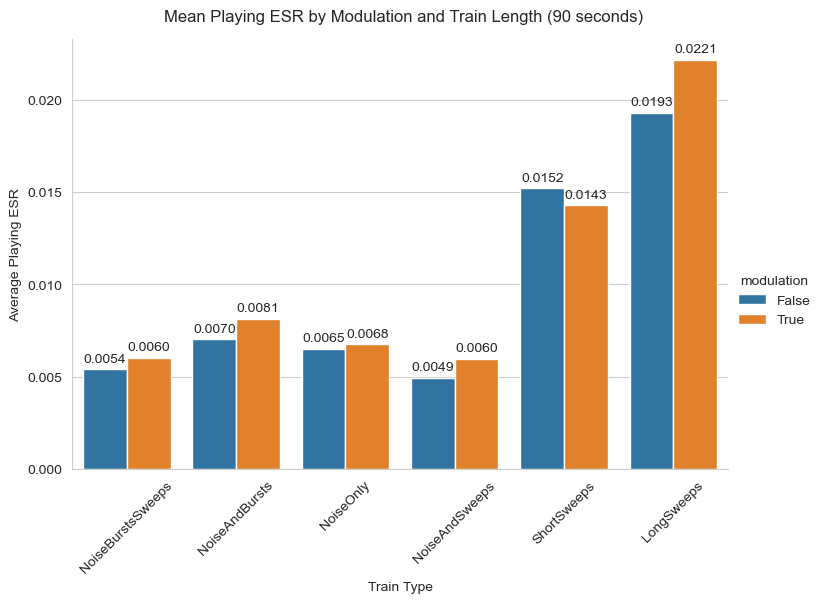

In [8827]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth[df_synth.train_length=='90'], 
    x='train_type', 
    y='playing_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Modulation and Train Length (90 seconds)", y=1.03)
plt.xticks(rotation=45)
plt.show()


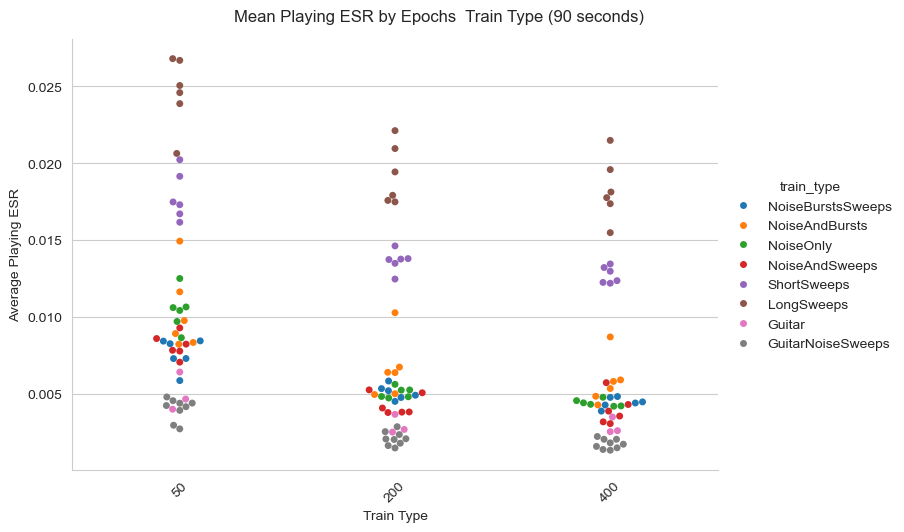

In [8828]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df[df.train_length=='90'], 
    x='epochs', 
    y='playing_ESR', 
    hue='train_type', 
    kind='swarm', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Epochs  Train Type (90 seconds)", y=1.03)
plt.xticks(rotation=45)
plt.show()


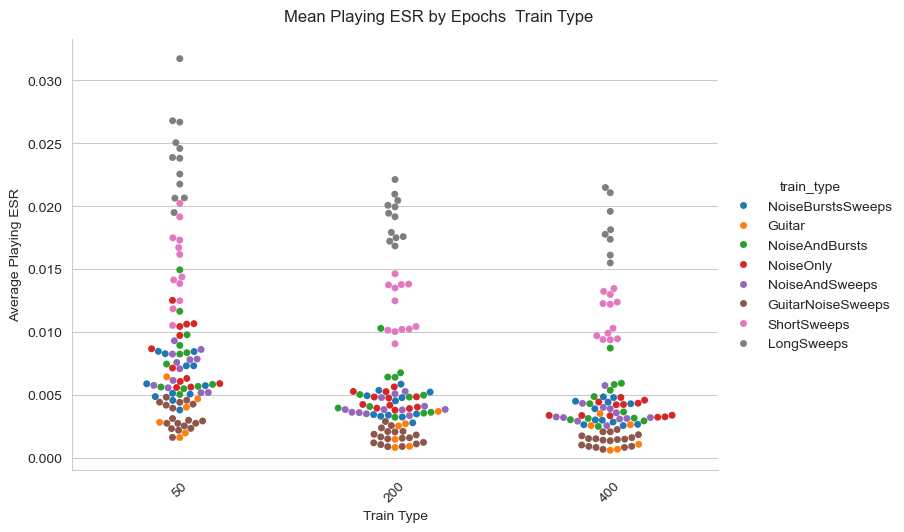

In [8829]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='epochs', 
    y='playing_ESR', 
    hue='train_type', 
    kind='swarm', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Epochs  Train Type", y=1.03)
plt.xticks(rotation=45)
plt.show()


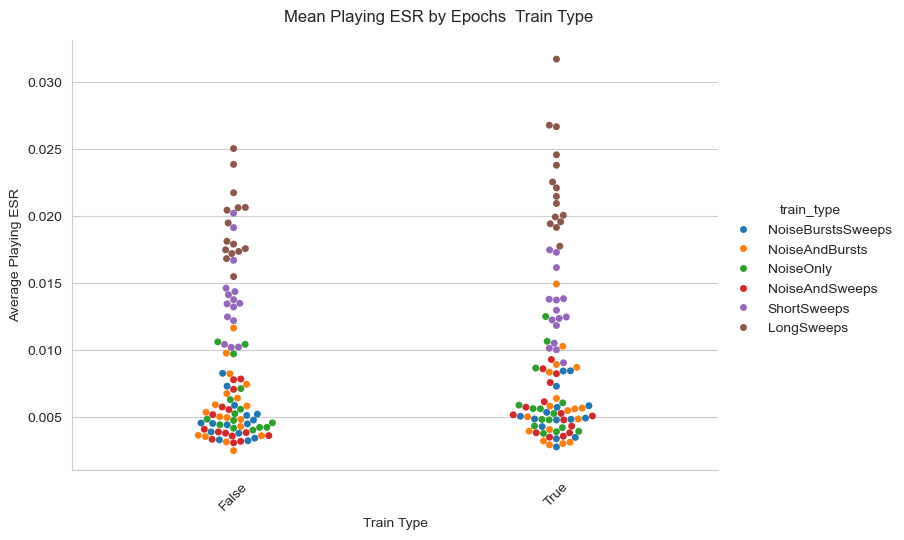

In [8830]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='modulation', 
    y='playing_ESR', 
    hue='train_type', 
    kind='swarm', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Epochs  Train Type", y=1.03)
plt.xticks(rotation=45)
plt.show()


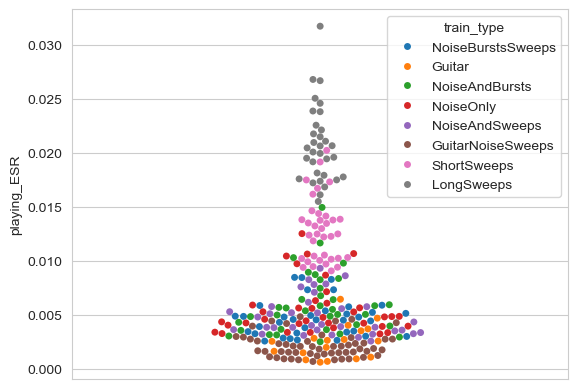

In [8831]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.swarmplot(
    data=df, 
    #x='modulation', 
    y='playing_ESR', 
    hue='train_type', 
    #kind='swarm', 
    #errorbar=None, # Removes confidence interval bars, just showing the mean
    #height=5, 
    #aspect=1.5,
    #order=my_order
)



plt.show()


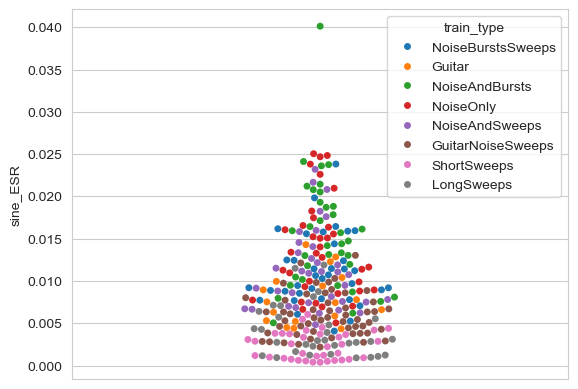

In [8832]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.swarmplot(
    data=df, 
    #x='modulation', 
    y='sine_ESR', 
    hue='train_type', 
    #kind='swarm', 
    #errorbar=None, # Removes confidence interval bars, just showing the mean
    #height=5, 
    #aspect=1.5,
    #order=my_order
)



plt.show()


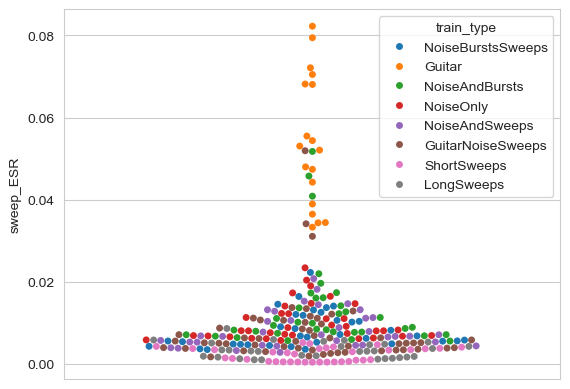

In [8833]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.swarmplot(
    data=df, 
    #x='modulation', 
    y='sweep_ESR', 
    hue='train_type', 
    #kind='swarm', 
    #errorbar=None, # Removes confidence interval bars, just showing the mean
    #height=5, 
    #aspect=1.5,
    #order=my_order
)



plt.show()


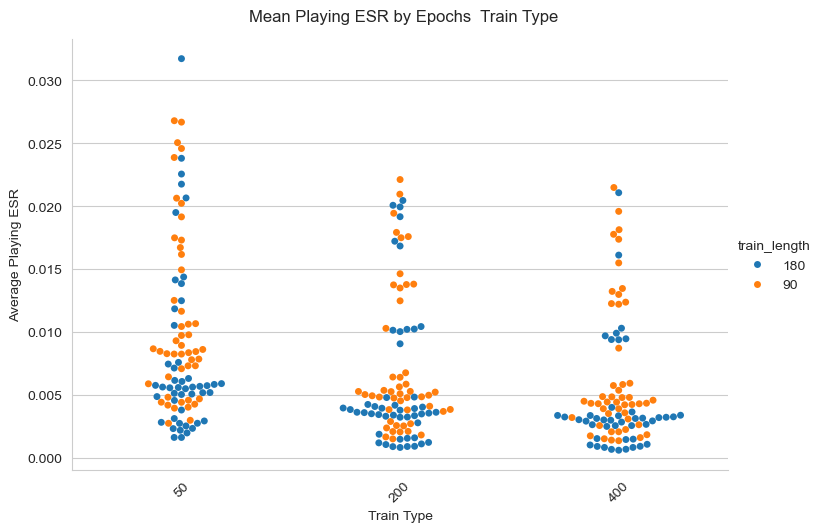

In [8834]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df, 
    x='epochs', 
    y='playing_ESR', 
    hue='train_length', 
    kind='swarm', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Train Type", "Average Playing ESR")
g.fig.suptitle("Mean Playing ESR by Epochs  Train Type", y=1.03)
plt.xticks(rotation=45)
plt.show()


# Modulation and Sine ESR

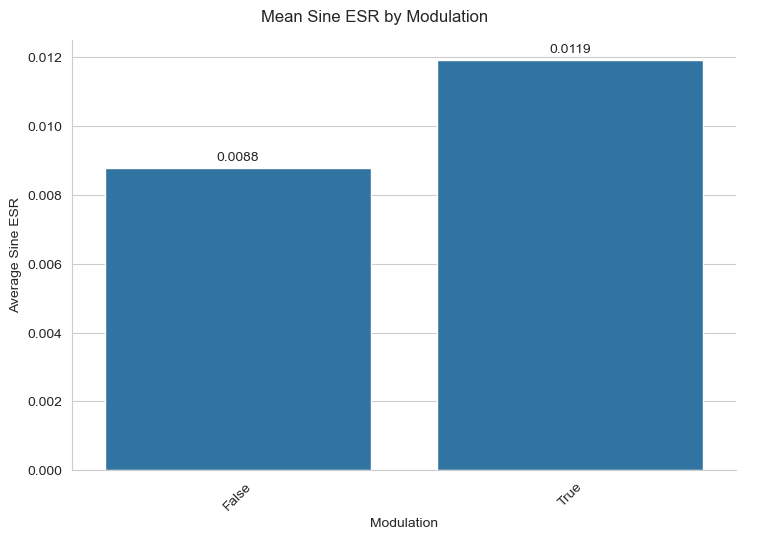

In [8835]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df_synth.groupby('modulation')['sine_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='modulation', 
    y='sine_ESR', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Sine ESR")
g.fig.suptitle("Mean Sine ESR by Modulation", y=1.03)
plt.xticks(rotation=45)
plt.show()


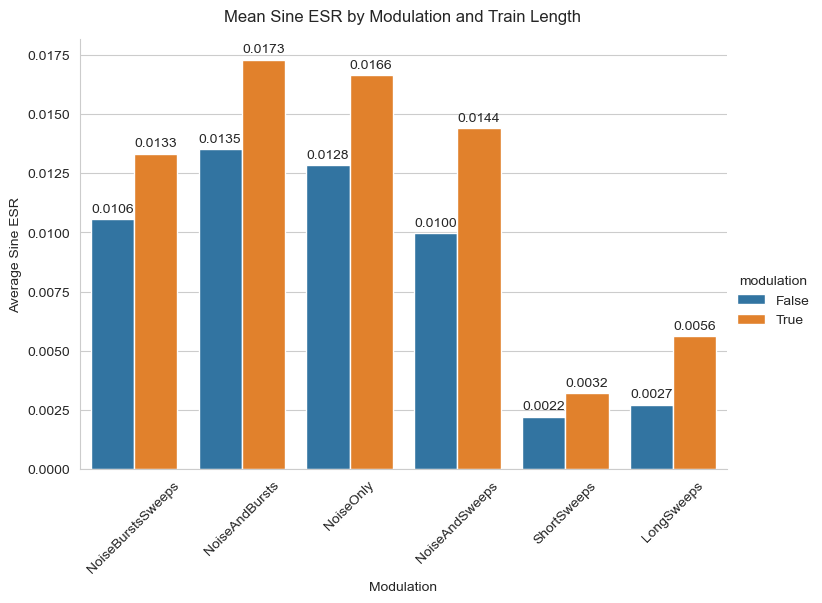

In [8836]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='train_type', 
    y='sine_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Sine ESR")
g.fig.suptitle("Mean Sine ESR by Modulation and Train Length", y=1.03)
plt.xticks(rotation=45)
plt.show()


# Modulation and Sweep ESR

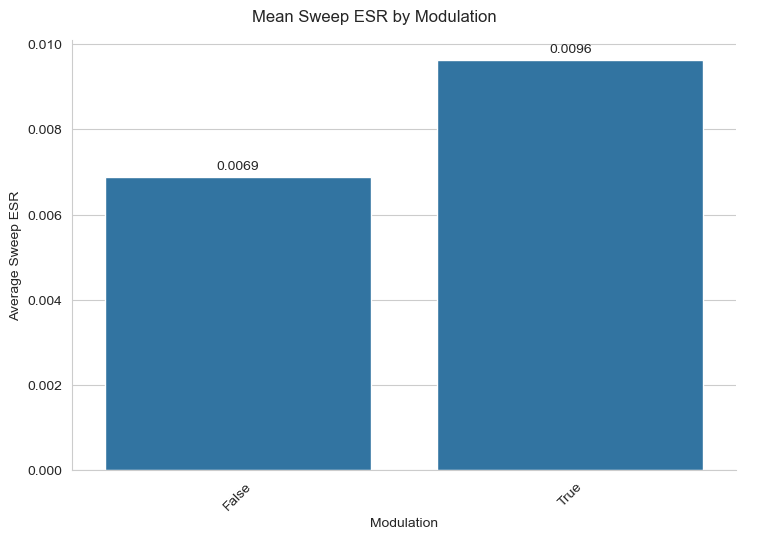

In [8837]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

my_order = df_synth.groupby('modulation')['sweep_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='modulation', 
    y='sweep_ESR', 
    #hue='train_length', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Sweep ESR")
g.fig.suptitle("Mean Sweep ESR by Modulation", y=1.03)
plt.xticks(rotation=45)
plt.show()


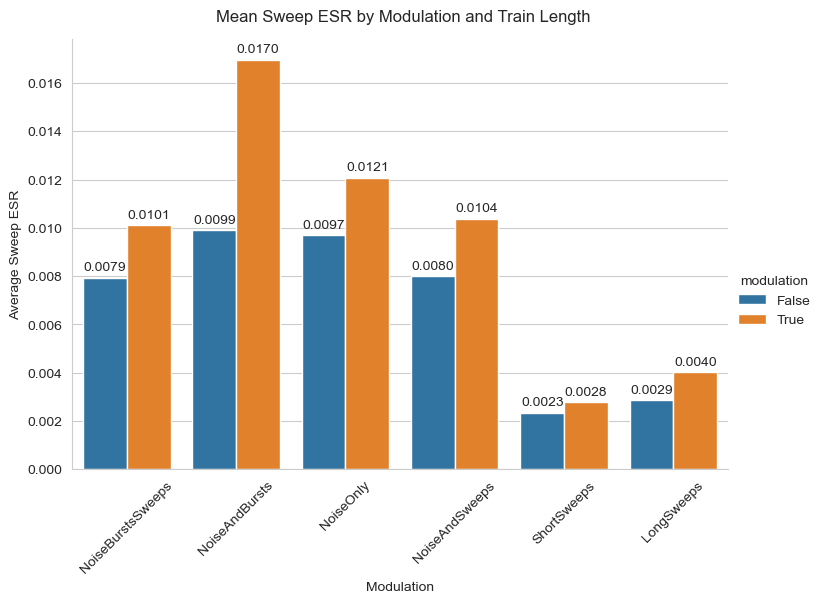

In [8838]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
sns.set_style("whitegrid")

#my_order = df_synth.groupby('modulation')['playing_ESR'].mean().sort_values().index

g = sns.catplot(
    data=df_synth, 
    x='train_type', 
    y='sweep_ESR', 
    hue='modulation', 
    kind='bar', 
    errorbar=None, # Removes confidence interval bars, just showing the mean
    height=5, 
    aspect=1.5,
    #order=my_order
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)


g.set_axis_labels("Modulation", "Average Sweep ESR")
g.fig.suptitle("Mean Sweep ESR by Modulation and Train Length", y=1.03)
plt.xticks(rotation=45)
plt.show()


In [8839]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

In [8840]:
df.train_type.unique()

array(['NoiseBurstsSweeps', 'Guitar', 'NoiseAndBursts', 'NoiseOnly',
       'NoiseAndSweeps', 'GuitarNoiseSweeps', 'ShortSweeps', 'LongSweeps'],
      dtype=object)

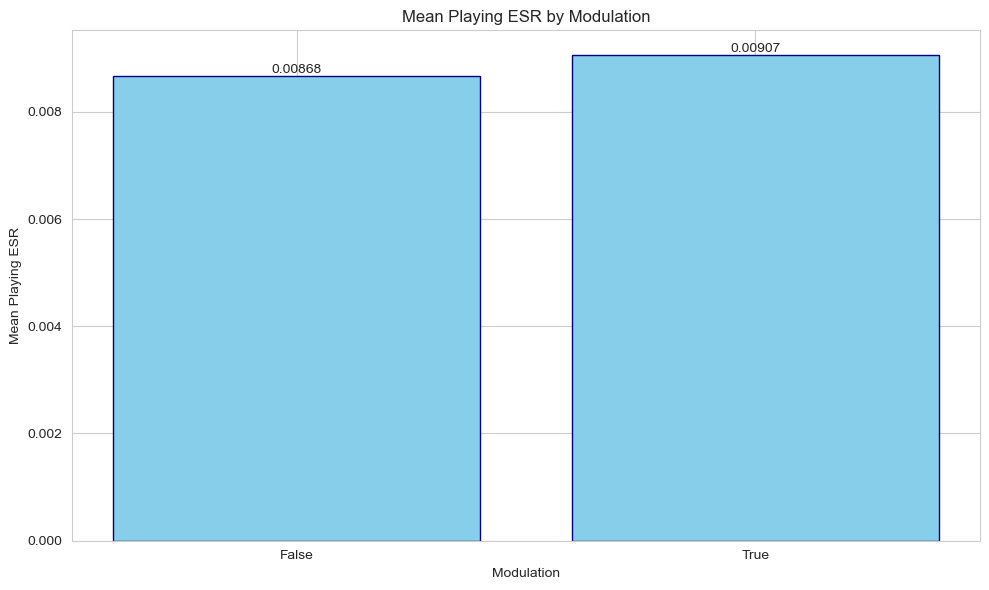

In [8841]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type!='Guitar')&(df.train_type!='GuitarNoiseSweeps')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation.png')

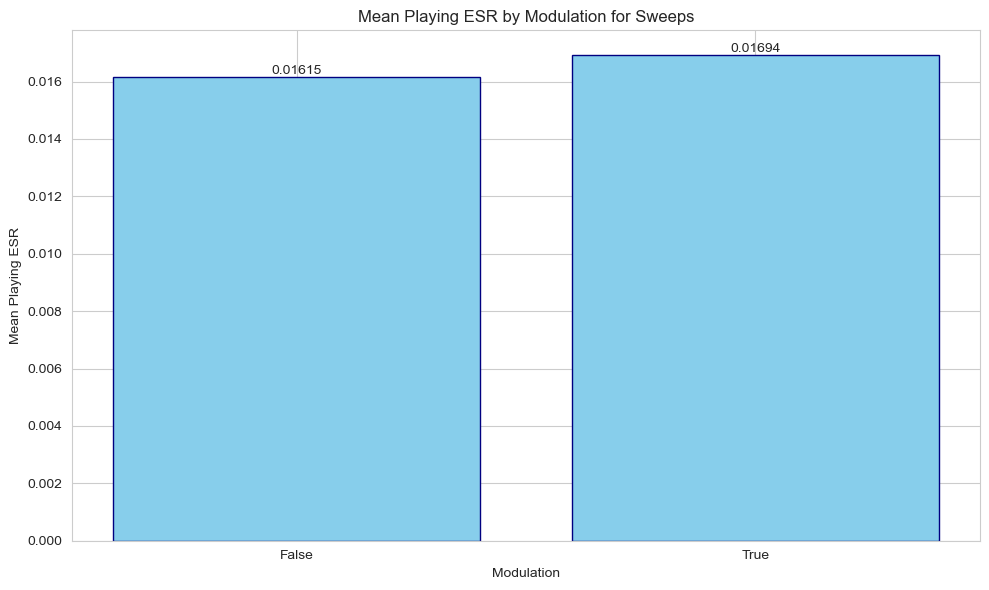

In [8842]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='LongSweeps')|(df.train_type=='ShortSweeps')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Sweeps')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_sweeps.png')

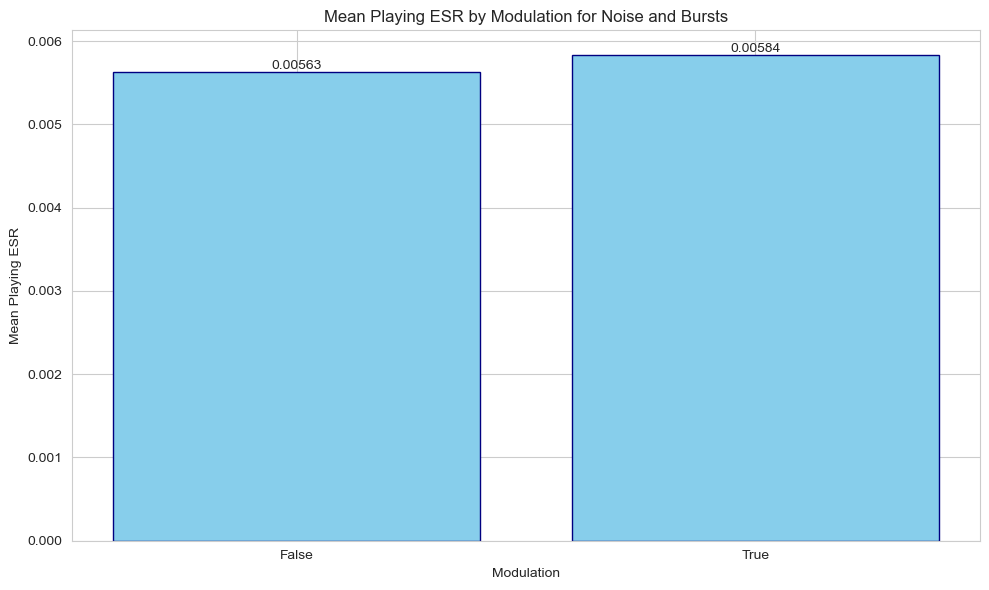

In [8843]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='NoiseOnly')|(df.train_type=='NoiseAndBursts')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Noise and Bursts')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_noise_and_bursts.png')

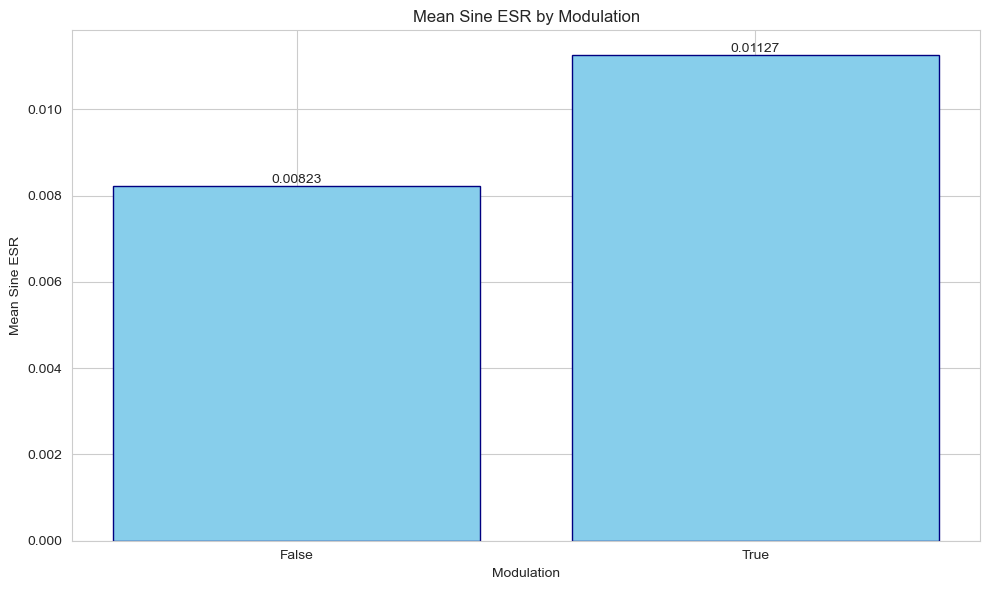

In [8844]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type!='Guitar')&(df.train_type!='GuitarNoiseSweeps')].groupby('modulation')['sine_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='sine_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['sine_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Sine ESR')
plt.title('Mean Sine ESR by Modulation')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_sine_ESR_by_modulation.png')

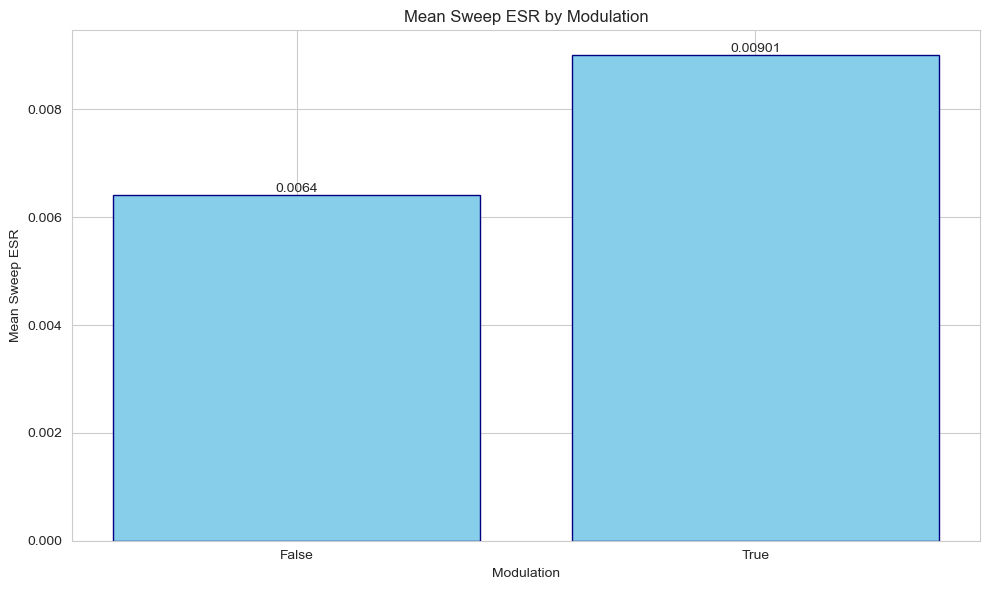

In [8845]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type!='Guitar')&(df.train_type!='GuitarNoiseSweeps')].groupby('modulation')['sweep_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='sweep_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['sweep_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Sweep ESR')
plt.title('Mean Sweep ESR by Modulation')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_sweep_ESR_by_modulation.png')

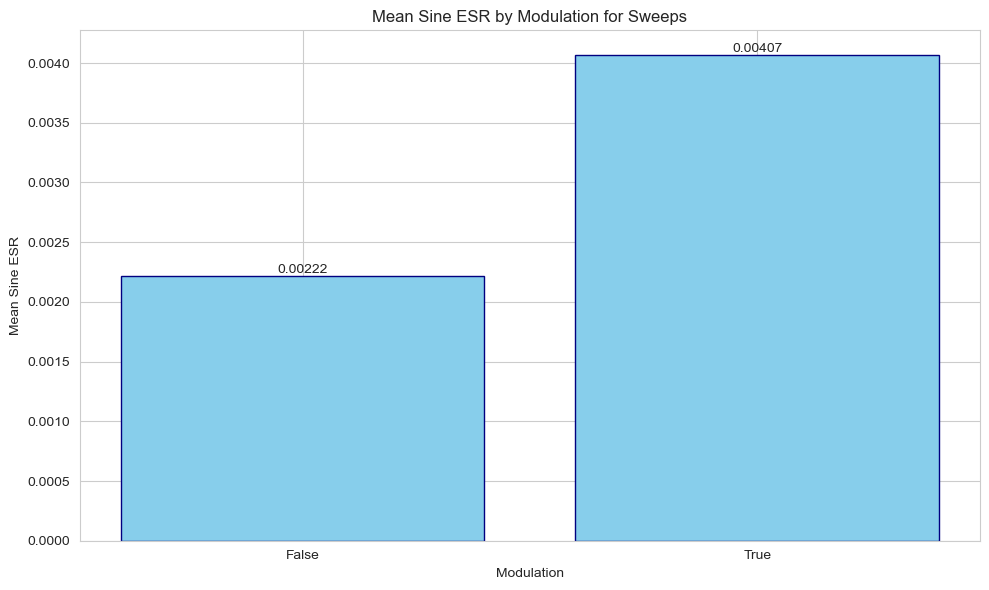

In [8846]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='LongSweeps')|(df.train_type=='ShortSweeps')].groupby('modulation')['sine_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='sine_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['sine_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Sine ESR')
plt.title('Mean Sine ESR by Modulation for Sweeps')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_sine_ESR_by_modulation_for_sweeps.png')

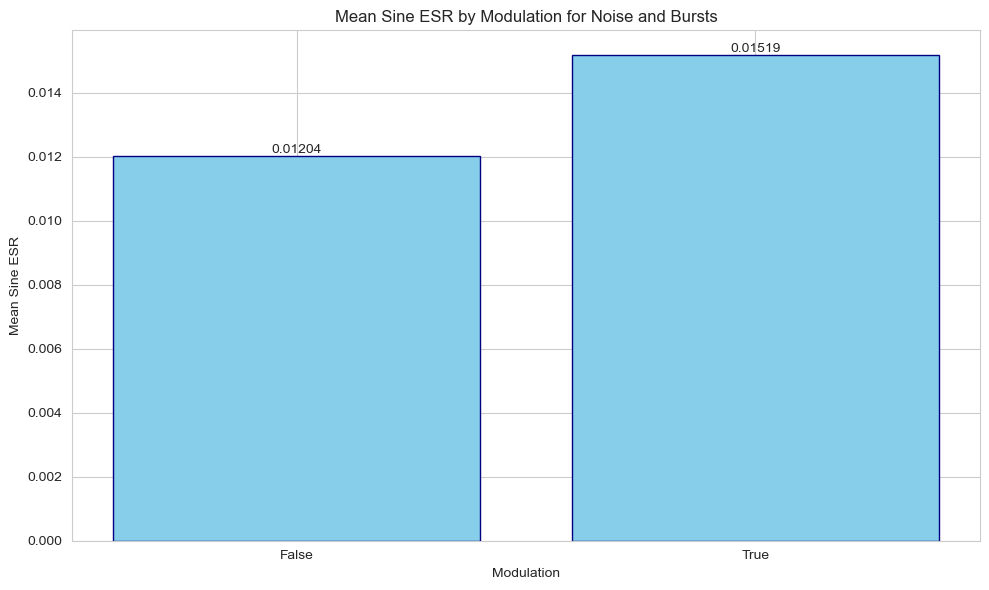

In [8847]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='NoiseOnly')|(df.train_type=='NoiseAanBursts')].groupby('modulation')['sine_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='sine_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['sine_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Sine ESR')
plt.title('Mean Sine ESR by Modulation for Noise and Bursts')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_sine_ESR_by_modulation_for_noise_and_bursts.png')

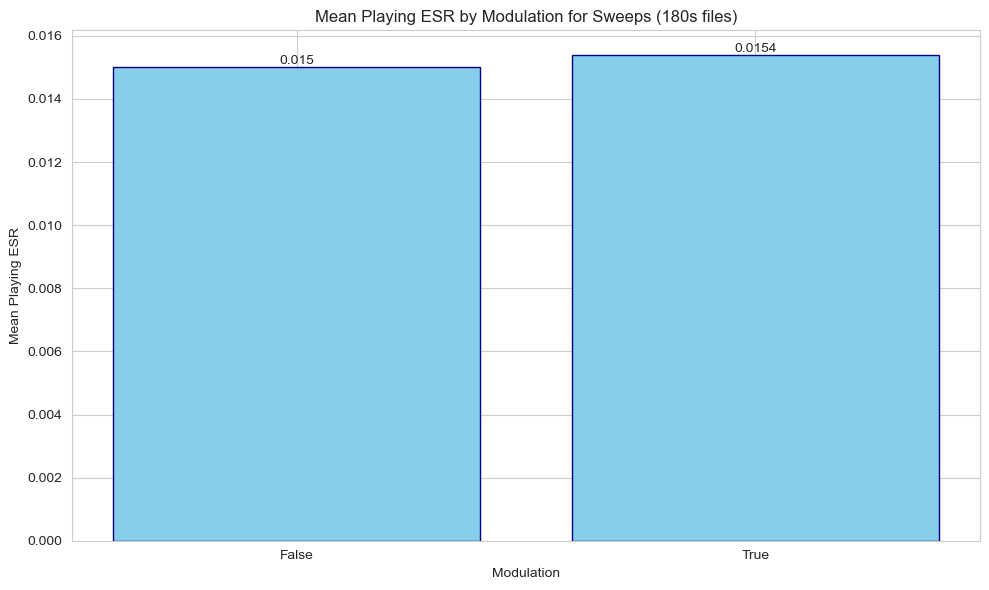

In [8848]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df_180[(df_180.train_type=='LongSweeps')|(df_180.train_type=='ShortSweeps')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Sweeps (180s files)')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_sweeps.png')

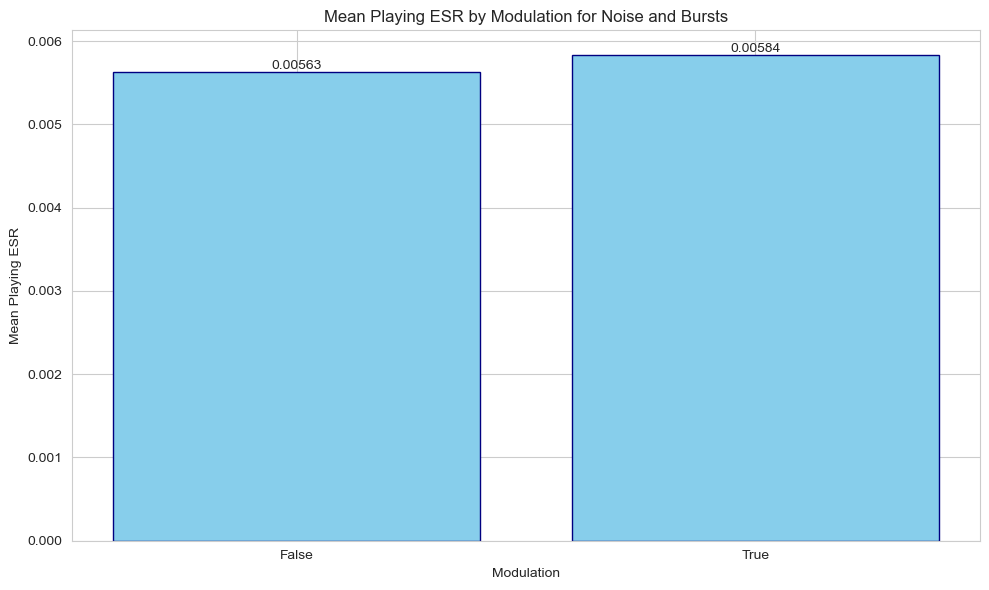

In [8849]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='NoiseOnly')|(df.train_type=='NoiseAndBursts')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Noise and Bursts')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_noise_and_bursts.png')

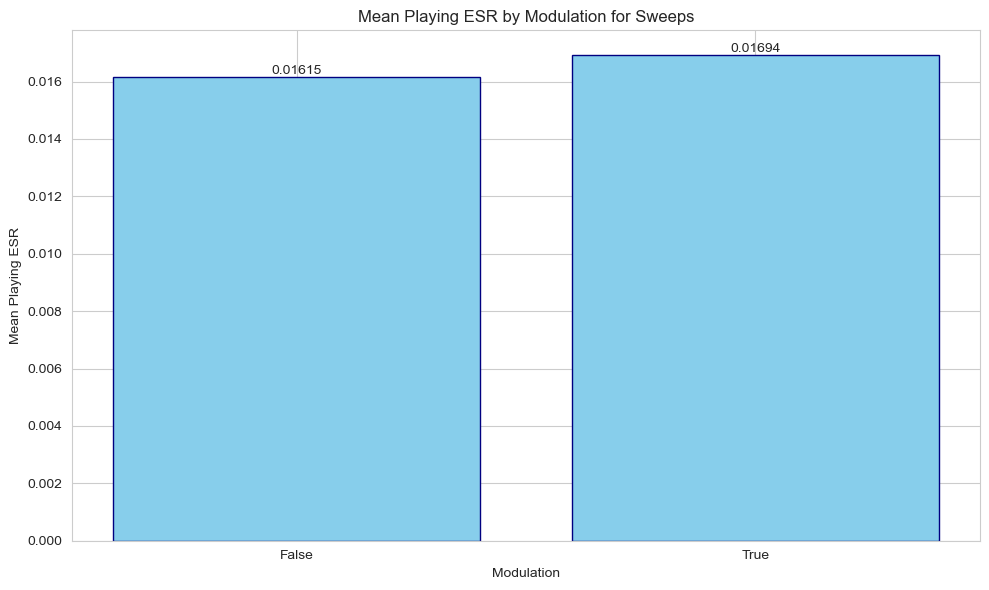

In [8850]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df[(df.train_type=='LongSweeps')|(df.train_type=='ShortSweeps')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Sweeps')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_sweeps.png')

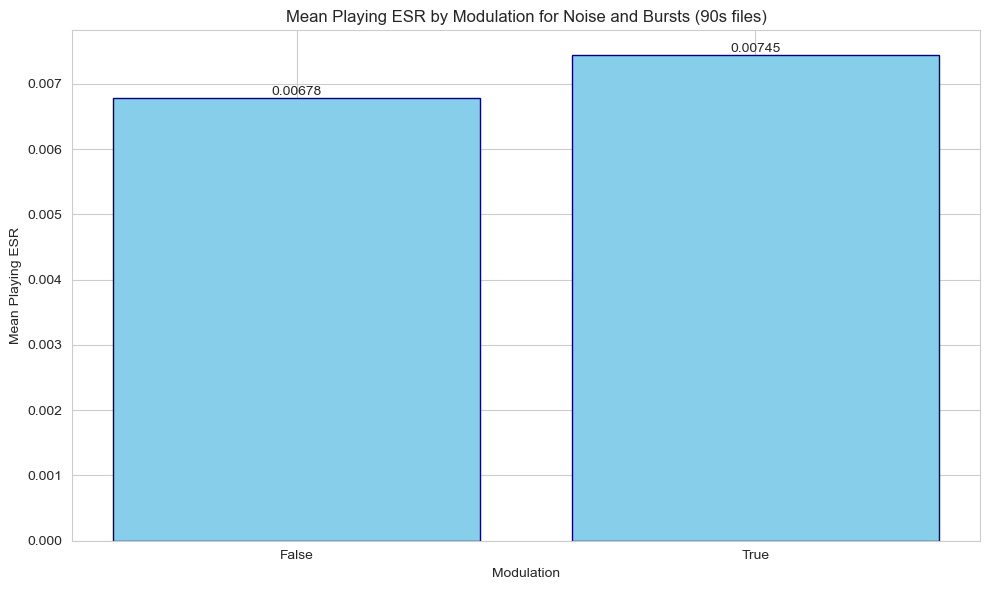

In [8851]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data and calculate the mean
# Replace 'df' with your actual DataFrame name
mean_esr = df_90[(df_90.train_type=='NoiseOnly')|(df_90.train_type=='NoiseAndBursts')].groupby('modulation')['playing_ESR'].mean().reset_index()

# 2. Sort the categories by the mean value (descending order)
#mean_esr = mean_esr.sort_values(by='playing_ESR', ascending=True)

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_esr['modulation'], mean_esr['playing_ESR'], color='skyblue', edgecolor='navy')

# 4. Add labels and title
plt.xlabel('Modulation')
plt.ylabel('Mean Playing ESR')
plt.title('Mean Playing ESR by Modulation for Noise and Bursts (90s files)')

# 5. Add value labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('mean_playing_ESR_by_modulation_for_noise_and_bursts.png')

In [8852]:
df.columns

Index(['train_label', 'validation_esr', 'seed', 'epochs', 'latency',
       'model_type', 'sine_shift_samples', 'sine_shift_ms', 'sine_ESR',
       'sine_RMSE', 'sine_MAE', 'sine_SpecMagL2', 'sine_ref_rms',
       'sine_est_rms', 'sweep_shift_samples', 'sweep_shift_ms', 'sweep_ESR',
       'sweep_RMSE', 'sweep_MAE', 'sweep_SpecMagL2', 'sweep_ref_rms',
       'sweep_est_rms', 'playing_shift_samples', 'playing_shift_ms',
       'playing_ESR', 'playing_RMSE', 'playing_MAE', 'playing_SpecMagL2',
       'playing_ref_rms', 'playing_est_rms', 'playing_ESR_attack',
       'playing_ESR_sustain', 'playing_ESR_decay', 'playing_frac_silence',
       'playing_frac_attack', 'playing_frac_sustain', 'playing_frac_decay',
       'train_type', 'amp_type', 'train_length', 'modulation', 'seed/version',
       'playing_rms_ratio'],
      dtype='object')

In [8853]:
df[[
    'train_type',
    'train_length',
  #  'modulation',
  #  'seed/version',
    'epochs', 
    'sine_ESR', 
    'sweep_ESR', 
    'playing_ESR', 
    'playing_SpecMagL2', 
    'playing_ESR_attack',
    'playing_ESR_sustain',
    'playing_ESR_decay'
]].head()

,train_type,train_length,epochs,sine_ESR,sweep_ESR,playing_ESR,playing_SpecMagL2,playing_ESR_attack,playing_ESR_sustain,playing_ESR_decay
0,NoiseBurstsSweeps,180,50,0.010720,0.008590,0.003781,11.653186,0.004690,0.003403,0.003474
1,NoiseBurstsSweeps,180,50,0.011214,0.010593,0.004546,12.850768,0.004948,0.004434,0.004272
2,NoiseBurstsSweeps,180,50,0.016443,0.012553,0.004850,13.717502,0.005782,0.004645,0.004454
3,NoiseBurstsSweeps,180,50,0.014392,0.014070,0.005720,14.446068,0.007232,0.005367,0.005084
4,NoiseBurstsSweeps,180,50,0.008787,0.007153,0.005112,14.491300,0.005427,0.005164,0.004756


In [8854]:
df_melt = df[[
    'train_type',
    'train_length',
  #  'modulation',
  #  'seed/version',
    'epochs', 
    'sine_ESR', 
    'sweep_ESR', 
    'playing_ESR', 
    'playing_SpecMagL2', 
    'playing_ESR_attack',
    'playing_ESR_sustain',
    'playing_ESR_decay'
]].melt(id_vars=['train_type', 'train_length', 'epochs'], var_name='Metric', value_name='Value')
df_melt

,train_type,train_length,epochs,Metric,Value
0,NoiseBurstsSweeps,180,50,sine_ESR,0.010720
1,NoiseBurstsSweeps,180,50,sine_ESR,0.011214
2,NoiseBurstsSweeps,180,50,sine_ESR,0.016443
3,NoiseBurstsSweeps,180,50,sine_ESR,0.014392
4,NoiseBurstsSweeps,180,50,sine_ESR,0.008787
...,...,...,...,...,...
1983,ShortSweeps,180,400,playing_ESR_decay,0.008684
1984,ShortSweeps,180,400,playing_ESR_decay,0.009027
1985,ShortSweeps,180,400,playing_ESR_decay,0.008783
1986,LongSweeps,180,400,playing_ESR_decay,0.015062


In [8855]:
df_melt.groupby(['train_type','epochs', 'Metric']).describe().head(35)

Value                       \
                                             count       mean       std   
train_type        epochs Metric                                           
Guitar            50     playing_ESR           6.0   0.003576  0.001821   
                         playing_ESR_attack    6.0   0.004997  0.002718   
                         playing_ESR_decay     6.0   0.003242  0.001668   
                         playing_ESR_sustain   6.0   0.003017  0.001508   
                         playing_SpecMagL2     6.0  12.647913  4.040386   
                         sine_ESR              6.0   0.011065  0.002707   
                         sweep_ESR             6.0   0.067802  0.012484   
                  200    playing_ESR           6.0   0.002008  0.001138   
                         playing_ESR_attack    6.0   0.002541  0.001469   
                         playing_ESR_decay     6.0   0.001875  0.001077   
                         playing_ESR_sustain   6.0   0.001780  0.001003   
                         playing_SpecMagL2     6.0   9.791903  3.815523   
                         sine_ESR              6.0   0.007044  0.001856   
                         sweep_ESR             6.0   0.048085  0.013420   
                  400    playing_ESR           6.0   0.001827  0.001218   
                         playing_ESR_attack    6.0   0.002192  0.001414   
                         playing_ESR_decay     6.0   0.001748  0.001197   
                         playing_ESR_sustain   6.0   0.001641  0.001110   
                         playing_SpecMagL2     6.0   9.474164  4.391164   
                         sine_ESR              6.0   0.005798  0.001590   
                         sweep_ESR             6.0   0.046215  0.013879   
GuitarNoiseSweeps 50     playing_ESR          18.0   0.003255  0.000979   
                         playing_ESR_attack   18.0   0.004225  0.001251   
                         playing_ESR_decay    18.0   0.003000  0.000921   
                         playing_ESR_sustain  18.0   0.002849  0.000936   
                         playing_SpecMagL2    18.0  11.189559  1.846716   
                         sine_ESR             18.0   0.008396  0.002206   
                         sweep_ESR            18.0   0.012410  0.010132   
                  200    playing_ESR          18.0   0.001673  0.000580   
                         playing_ESR_attack   18.0   0.002042  0.000737   
                         playing_ESR_decay    18.0   0.001546  0.000539   
                         playing_ESR_sustain  18.0   0.001512  0.000548   
                         playing_SpecMagL2    18.0   8.135063  1.635598   
                         sine_ESR             18.0   0.005185  0.001771   
                         sweep_ESR            18.0   0.006311  0.007083   

                                                                             \
                                                   min       25%        50%   
train_type        epochs Metric                                               
Guitar            50     playing_ESR          0.001600  0.002170   0.003405   
                         playing_ESR_attack   0.002073  0.003018   0.004984   
                         playing_ESR_decay    0.001429  0.001958   0.003027   
                         playing_ESR_sustain  0.001395  0.001826   0.002804   
                         playing_SpecMagL2    7.845197  9.621599  12.243412   
                         sine_ESR             0.006606  0.010065   0.011346   
                         sweep_ESR            0.052069  0.057831   0.069328   
                  200    playing_ESR          0.000806  0.001038   0.001990   
                         playing_ESR_attack   0.001022  0.001319   0.002593   
                         playing_ESR_decay    0.000757  0.000947   0.001819   
                         playing_ESR_sustain  0.000689  0.000937   0.001768   
                         playing_SpecMagL2    5.671963  6.451683   9.779596   
         